In [351]:
# Load Libraries
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold

# data manipulation 
import pandas as pd
import numpy as np

# plotting
import seaborn as sns
import matplotlib.pyplot as plt

# neuron visualizations
from brainrender import Scene
from brainrender.actors import Points

import vedo
vedo.settings.default_backend= 'vtk'

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy
from sklearn.metrics import make_scorer

#Custom function to computer the within cluster variance (will be used as custom scoring method for spectral clustering)
def compute_wcv(labels, X):
    wcv = 0
    for cluster in np.unique(labels):
        X_cluster = X[labels==cluster]
        centroid = np.mean(X_cluster,axis=0)
        wcv_cluster = ((X_cluster - centroid)**2).sum().sum()
        wcv += wcv_cluster
    return wcv

def spectral_scorer(estimator, X, y=None):
    labels = estimator.fit_predict(X)
    wcv = compute_wcv(labels, X)
    return -wcv

In [352]:
#want to do clustering on snr using the features the describe the projection type of the neurons,
#then we want to see if those clusters are reflected by the "proj" labels.

# load data
ec_snr_data = pd.read_csv("master_detailed_comment.csv")

ec_snr_data.head()


,mouseID,neuronNR,neuron_ID,FRP_endpoint,FRP_length,SS_endpoint,SS_length,VIS_endpoint,VIS_length,VISpor_endpoint,...,STRd_length,STRv_endpoint,STRv_length,x,y,z,comment,injection,proj,count
0,1056,2,1056_2,0,52.590655,0,0.00000,4,2850.742552,9,...,35586.500280,79,70750.246650,9662.4,3506.8,9755.3,NaN,ORB,rsp_orb,6
1,1056,41,1056_41,0,0.000000,0,0.00000,7,3031.117311,1,...,8835.140534,7,10849.726100,9791.9,3825.0,9756.8,NaN,ORB,rsp_orb,5
2,1056,6,1056_6,0,133.352838,15,15402.66771,11,12446.070610,1,...,57612.283980,71,69422.052800,9680.9,3897.0,9768.1,NaN,ORB,rsp_orb,8
3,1056,26,1056_26,0,0.000000,1,140.00601,11,9656.228320,17,...,30481.705940,16,7439.897194,9844.7,3033.5,9482.4,NA injection area has 0 endpoints injection ar...,ORB,NaN,6
4,1056,31,1056_31,0,148.433770,0,0.00000,0,0.000000,0,...,26718.999420,81,75650.137140,9232.8,4481.3,10019.4,NaN,ORB,orb,3


In [353]:
ec_snr_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 68 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mouseID          237 non-null    int64  
 1   neuronNR         237 non-null    int64  
 2   neuron_ID        237 non-null    object 
 3   FRP_endpoint     237 non-null    int64  
 4   FRP_length       237 non-null    float64
 5   SS_endpoint      237 non-null    int64  
 6   SS_length        237 non-null    float64
 7   VIS_endpoint     237 non-null    int64  
 8   VIS_length       237 non-null    float64
 9   VISpor_endpoint  237 non-null    int64  
 10  VISpor_length    237 non-null    float64
 11  RSP_endpoint     237 non-null    int64  
 12  RSP_length       237 non-null    float64
 13  PTLp_endpoint    237 non-null    int64  
 14  PTLp_length      237 non-null    float64
 15  ORB_endpoint     237 non-null    int64  
 16  ORB_length       237 non-null    float64
 17  MO_endpoint     

EDA


In [354]:
# To make this notebook's output identical at every run
rng = np.random.seed(0)

#Define the database that will be cleaned and preprocessed
df = ec_snr_data.copy()

#Keep in the database only the variables that explain connectivity patterns 
cols_to_drop = ["mouseID", "neuronNR", "neuron_ID", "x", "y", "z", "comment", "injection", "proj", "count"]

labels = df["proj"]
df = df.drop(columns=cols_to_drop)

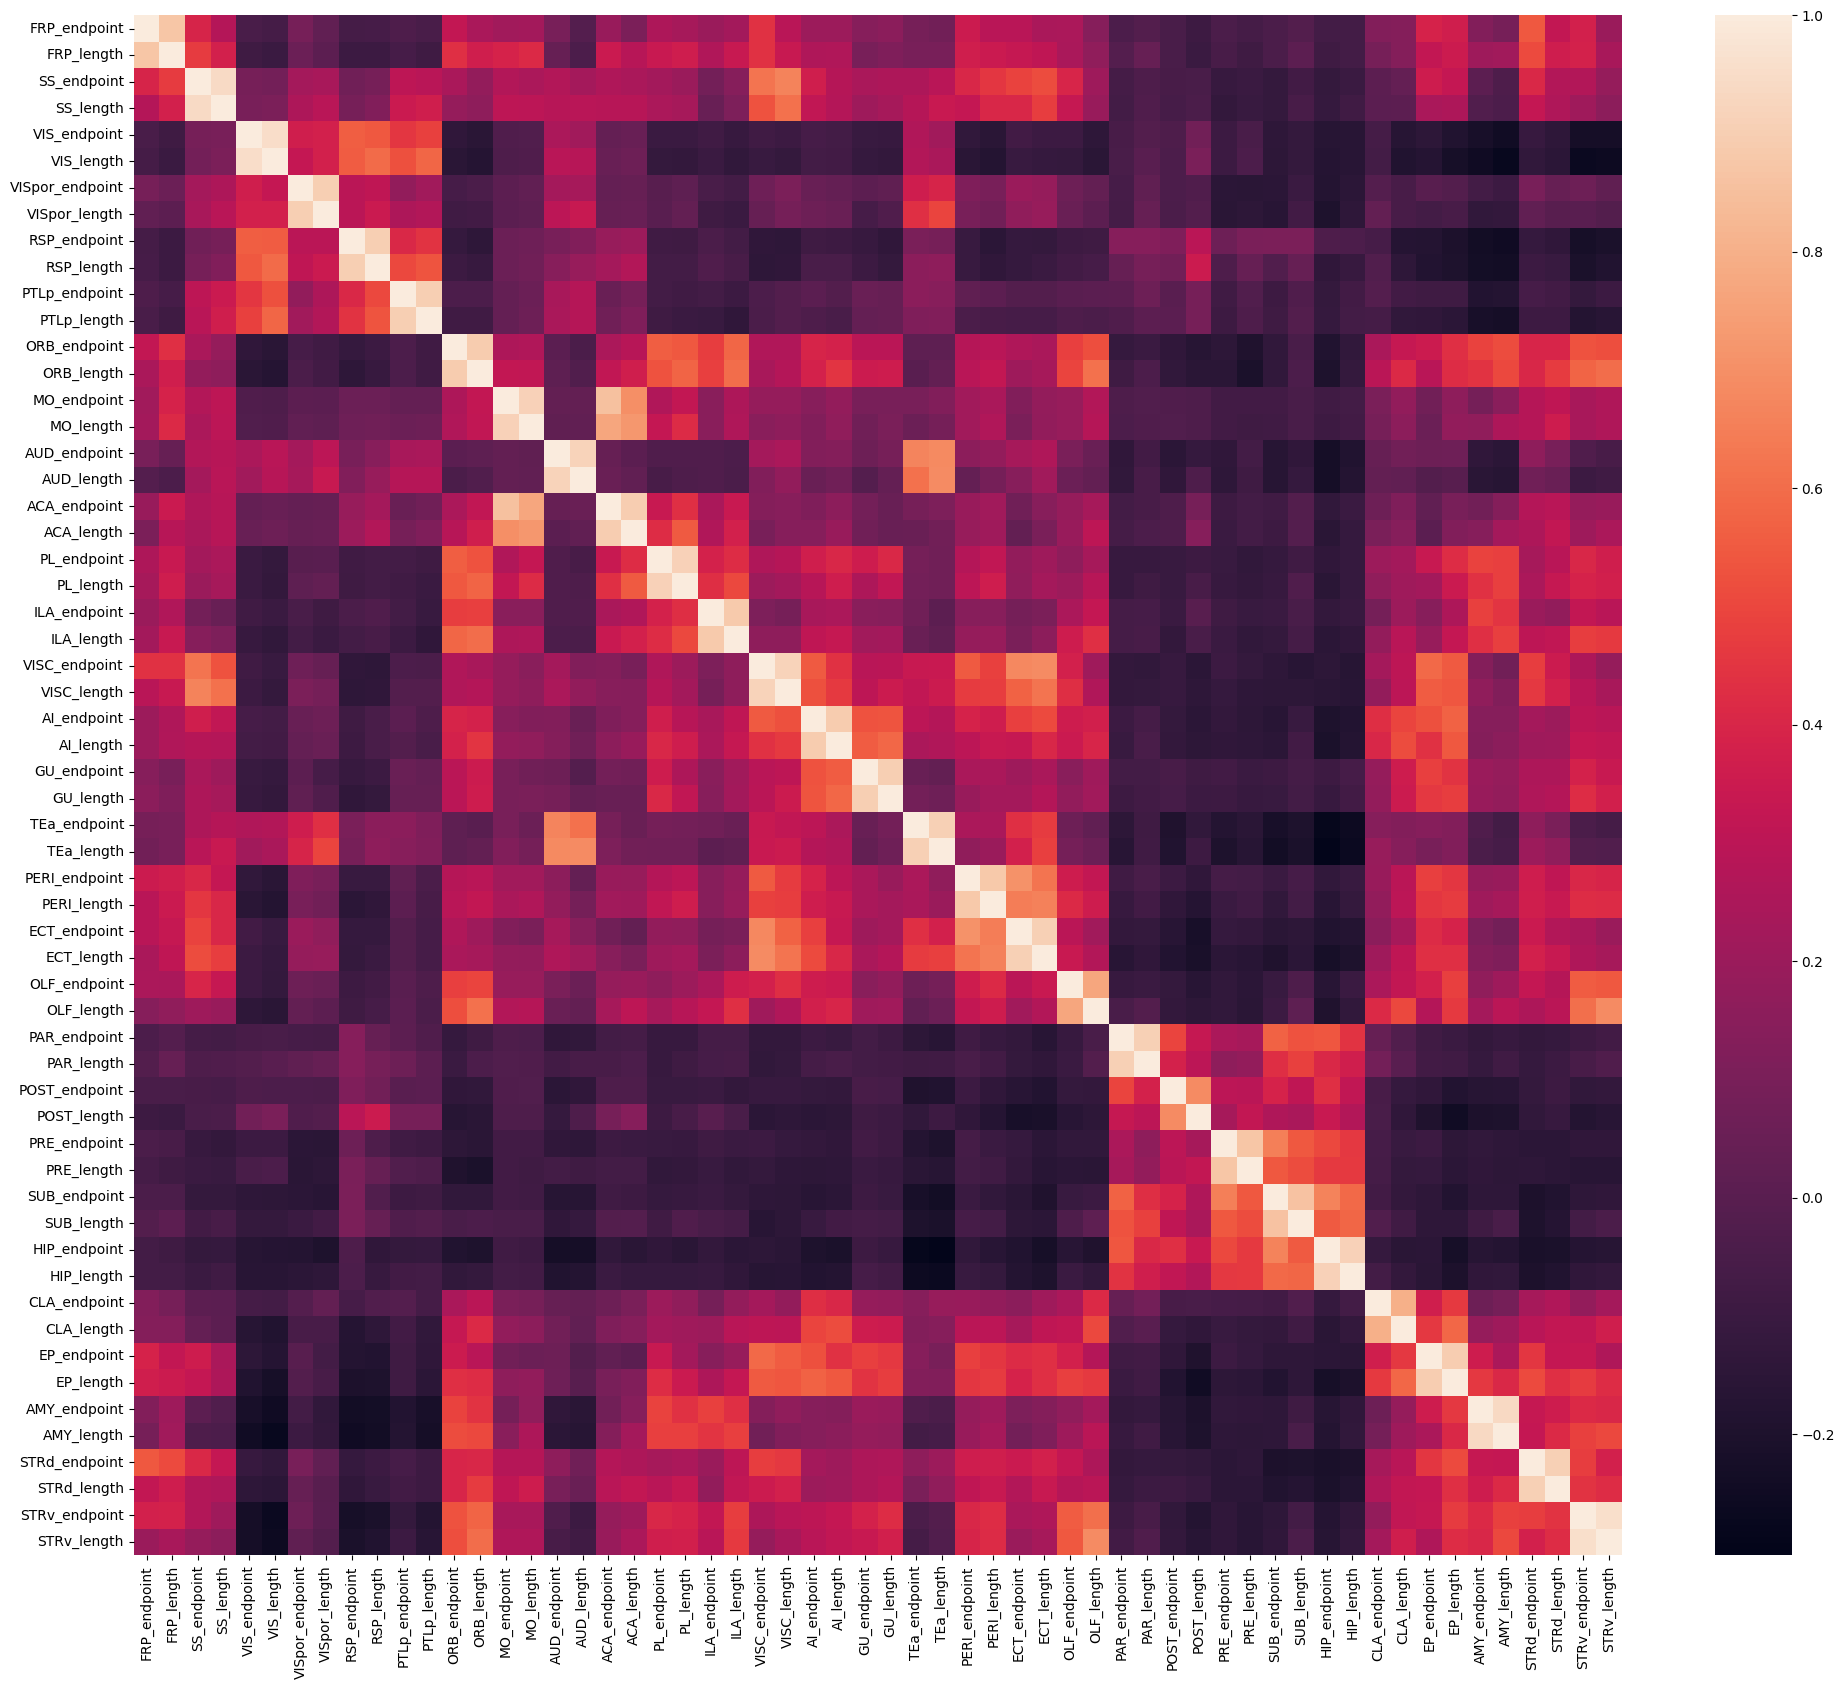

In [355]:
plt.figure(figsize=(24, 20))
sns.heatmap(df.corr())
plt.show()

Length and endpoint appear to be highly correlated, we can remove either one from each of the encoded regions. Moreover, we clearly see some structure in the correlation patterns. We can use PCA before clustering to capture to move to a lower dimensional space and then apply PCA on the lower dimensional space.

In [356]:
#Get the columns that end with "_endpoint"
endpoint_cols = []

for col in df.columns:
    if col.endswith("_endpoint"):
        endpoint_cols.append(col)

In [357]:
#Remove endpoint columns from the dataframe
df = df.drop(columns=endpoint_cols)

In [358]:
#df.head()
# for col in df.columns:
#     sns.histplot(data=df, x=col)
#     plt.tight_layout()
#     plt.show()

In [359]:
#df = np.log1p(df)

#df.head()
#for col in df.columns:
    #sns.histplot(data=df, x=col)
    #plt.tight_layout()
    #plt.show()

In [360]:
#Scale the data

scaler = StandardScaler()
df_transitory = scaler.fit_transform(df)

df = pd.DataFrame(
    df_transitory,
    columns = df.columns,
    index = df.index
)

PCA

In [361]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA


In [362]:
pca = PCA()
pca.fit(df)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

(0.0, 100.0)

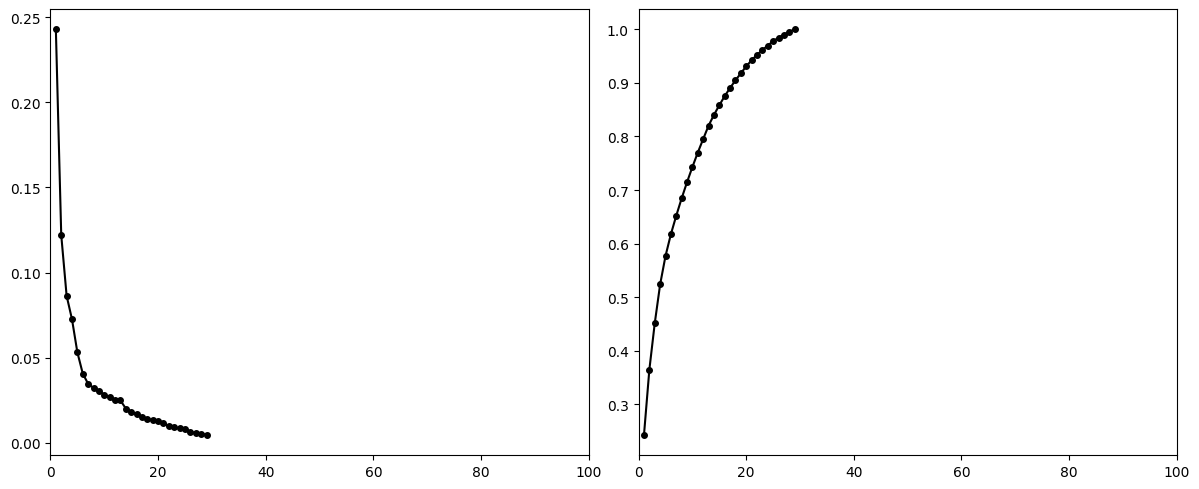

In [363]:
#selecting number of components
explained_var = pca.explained_variance_
explained_var_ratio = pca.explained_variance_ratio_
x = np.linspace(1,len(explained_var),len(explained_var))
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
ax[0].plot(x, explained_var_ratio[0:200], 'k-', marker = 'o', markersize=4)
ax[1].plot(x,explained_var_ratio.cumsum()[0:200], 'k-', marker = 'o', markersize=4)
fig.tight_layout()
ax[0].set_xlim(0,100)
ax[1].set_xlim(0,100)

the first 18 components explain more ore less 90% of variability

In [364]:
#Let's get the new feature matrix
pca2 = PCA(n_components = 18)
low_dim_df_trans = pca2.fit_transform(df)

In [365]:
low_dim_df = pd.DataFrame(
    low_dim_df_trans,
    columns = [f"PCA{i+1}" for i in range(low_dim_df_trans.shape[1])]
)

In [366]:
low_dim_df.head()
low_dim_df_array = np.asarray(low_dim_df)


Run clustering algorithm on the new dataframe - try hierarchical clustering first with different types of linkage

In [367]:
#get labels which will be used for plotting later

labels.value_counts() 
labels.head()
#Replace NAs with something else
labels = labels.fillna("NA")

In [368]:
print(f"Shape of labels pd serie {labels.shape}")
print(f"Shape of feature matrix {low_dim_df.shape}")

Shape of labels pd serie (237,)
Shape of feature matrix (237, 18)


In [369]:
# #Run hierarchical clustering
# hc_avg = hierarchy.linkage(low_dim_df, method='average')
# # Plot the dendrogram
# fig, ax = plt.subplots(1, 1, figsize=(40,20))
# hierarchy.dendrogram(hc_avg, ax=ax, labels=np.asarray(labels),
#                      color_threshold=13, above_threshold_color='black', leaf_font_size = 10)
# plt.show()


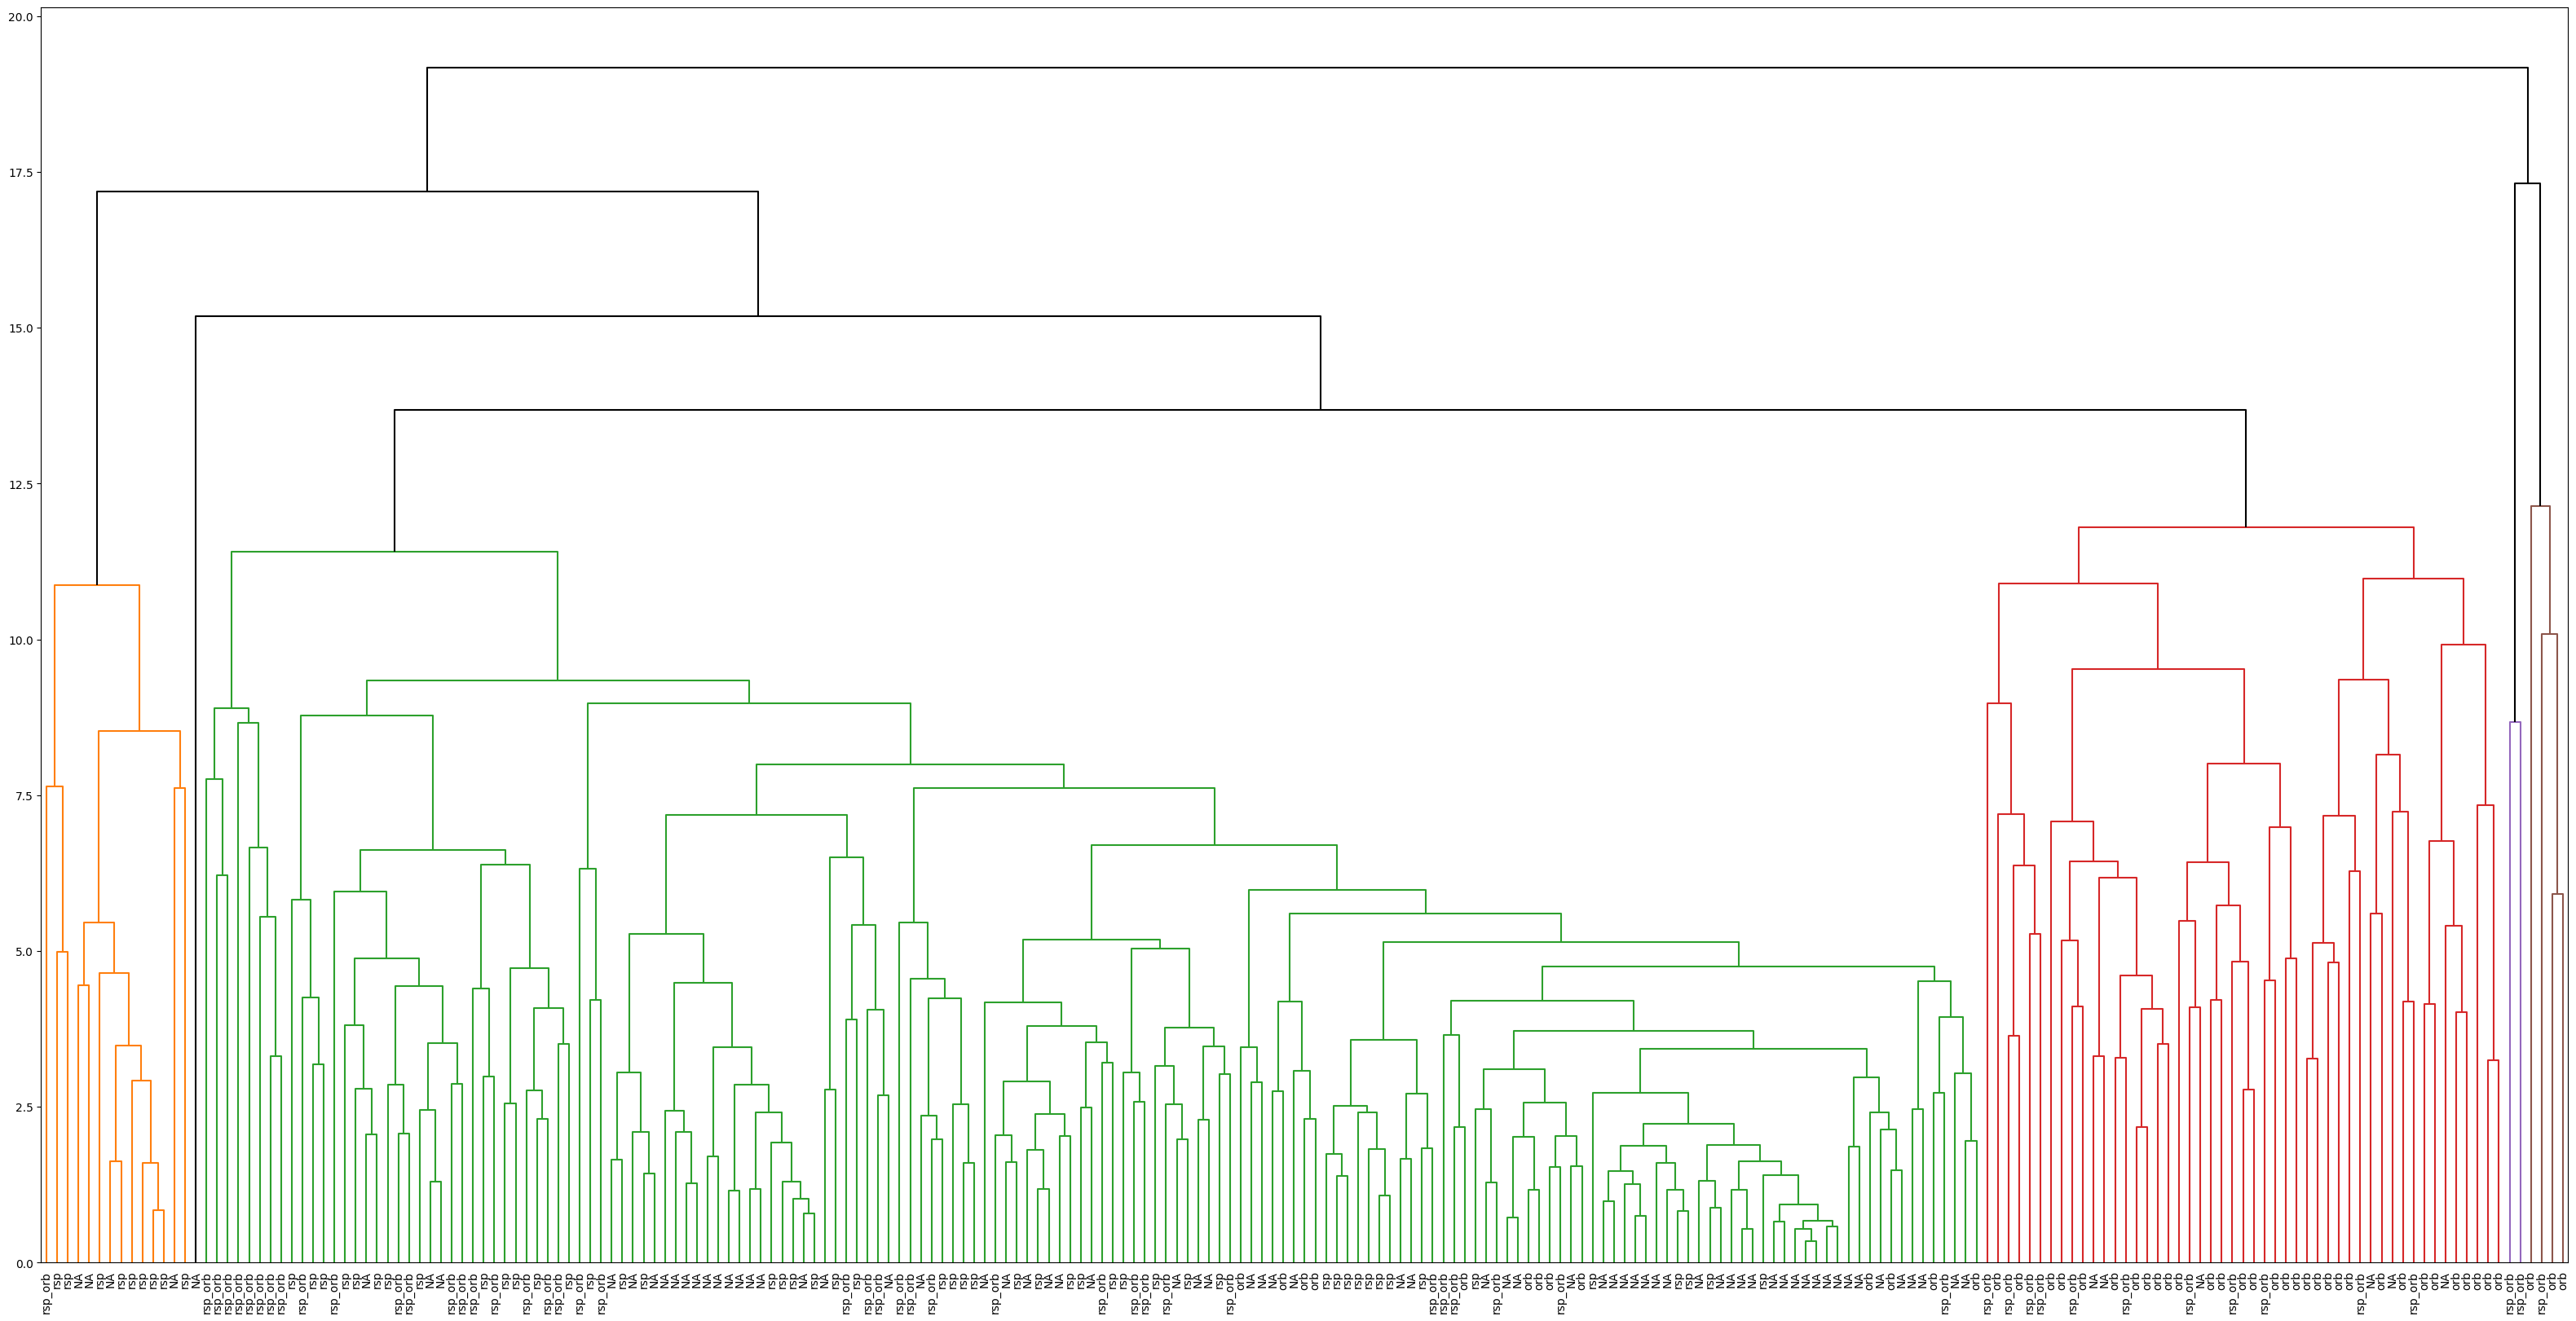

In [370]:
%matplotlib inline
#Run hierarchical clustering
hc_comp = hierarchy.linkage(low_dim_df, method='complete', metric="euclidean")
# Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(40,20))
hierarchy.dendrogram(hc_comp, ax=ax, labels=np.asarray(labels),
                     color_threshold=13, above_threshold_color='black', leaf_font_size = 10)
plt.show()

In [371]:
# #Run hierarchical clustering
# hc_single = hierarchy.linkage(low_dim_df, method='single')
# # Plot the dendrogram
# fig, ax = plt.subplots(1, 1, figsize=(40,20))
# hierarchy.dendrogram(hc_single, ax=ax, no_labels=True,
#                      color_threshold=13, above_threshold_color='black', leaf_font_size = 10)
# plt.show()

Complete linkage is preferred, more clear separation of clusters and high level merge occurs at larger euclidean distances

In [372]:
cluster_labels = hierarchy.cut_tree(hc_comp, height=13)
cluster_labels_1d = cluster_labels[:, 0]
ct = pd.crosstab(cluster_labels_1d, labels)
ct



proj,NA,orb,rsp,rsp_orb
row_0,,,,
0,6,32,0,11
1,66,13,49,39
2,4,0,9,1
3,0,0,0,2
4,0,3,0,1
5,1,0,0,0


In [373]:
wcv_comp = compute_wcv(cluster_labels_1d, low_dim_df)
print(f"Total WCV: {wcv_comp}")

Total WCV: 4123.152352218547


In [374]:
# fig, ax = plt.subplots(figsize=(10,6))
# ax.scatter(low_dim_df_array[:,0], low_dim_df_array[:,1], c=cluster_labels_1d, cmap="viridis")
# plt.show()

In [375]:
import plotly.express as px
import pandas as pd

plot_df = low_dim_df.copy()
plot_df.columns = [f"Dim_{i+1}" for i in range(plot_df.shape[1])]
plot_df["cluster"] = cluster_labels_1d.astype(str)

fig = px.scatter_3d(
    plot_df,
    x="Dim_1",
    y="Dim_2",
    z="Dim_3",
    color="cluster",
    hover_data=plot_df.columns
)

fig.show()

ct = pd.crosstab(cluster_labels_1d, labels)
print(ct)

proj   NA  orb  rsp  rsp_orb
row_0                       
0       6   32    0       11
1      66   13   49       39
2       4    0    9        1
3       0    0    0        2
4       0    3    0        1
5       1    0    0        0


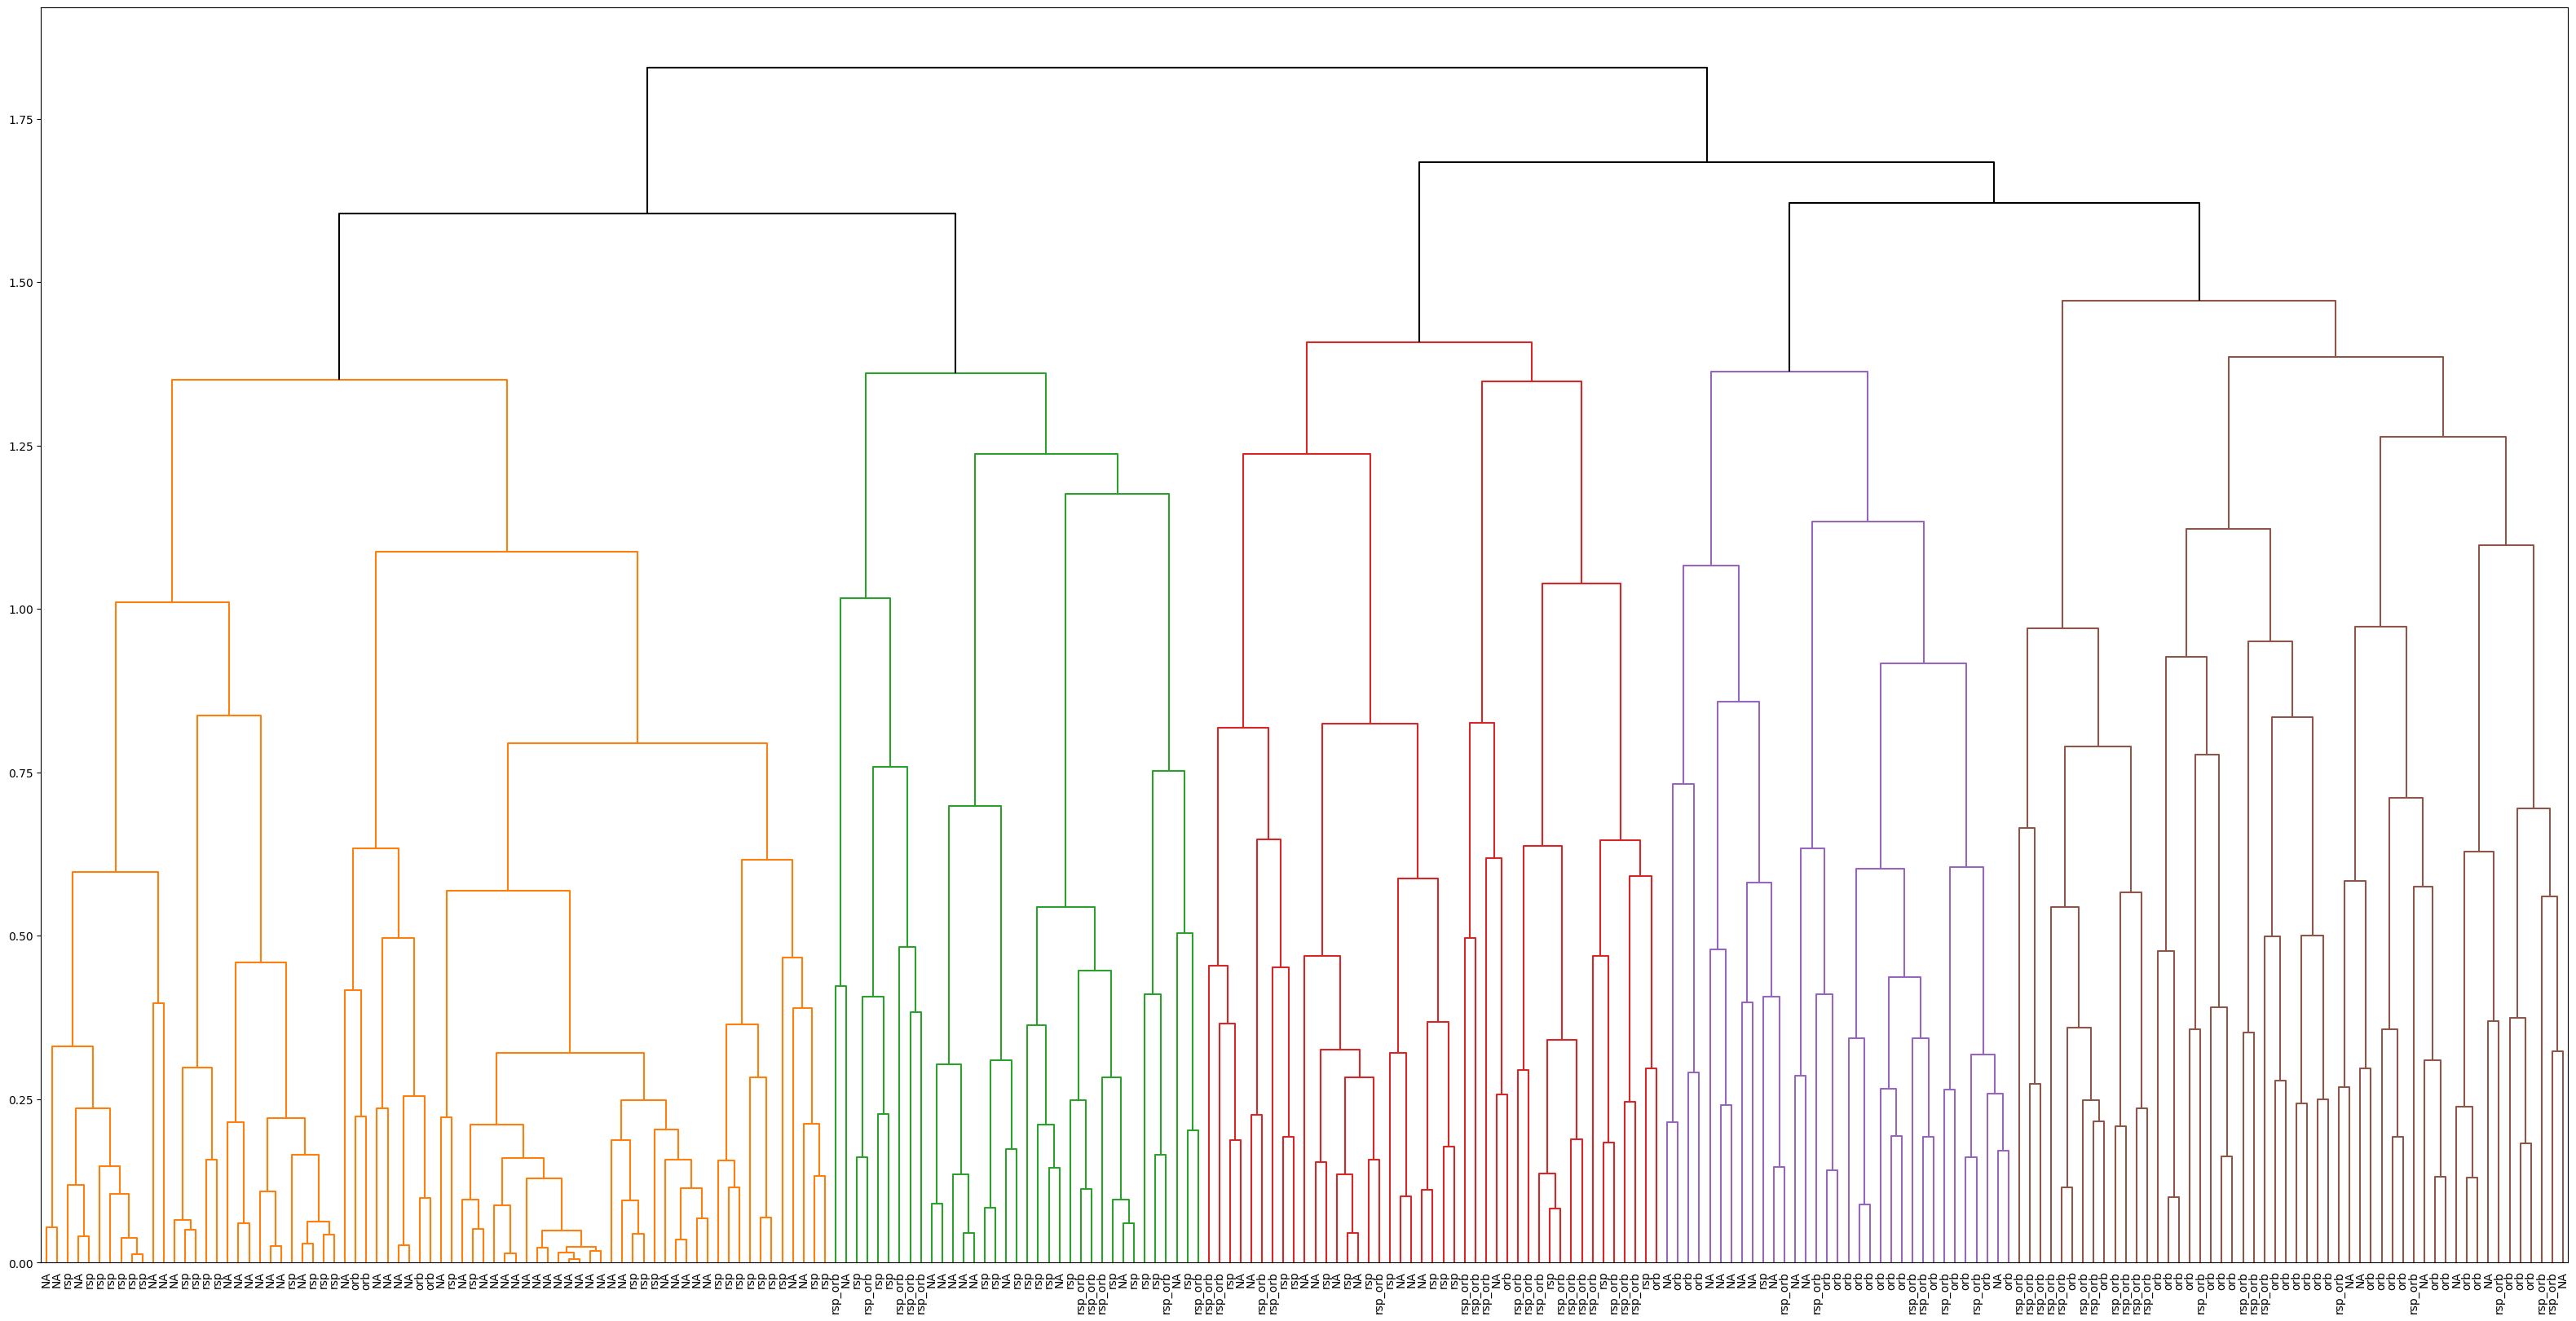

In [376]:
hc_comp_cos = hierarchy.linkage(low_dim_df, method="complete", metric="cosine")
# Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(40,20))
hierarchy.dendrogram(hc_comp_cos, ax=ax, labels=np.asarray(labels),
                     color_threshold=1.5, above_threshold_color='black', leaf_font_size = 10)
plt.show()

In [377]:
cluster_labels = hierarchy.cut_tree(hc_comp_cos, height=1.5)
cluster_labels_1d_2 = cluster_labels[:, 0]

plot_df2 = low_dim_df.copy()
plot_df2.columns = [f"Dim_{i+1}" for i in range(plot_df2.shape[1])]
plot_df2["cluster"] = cluster_labels_1d_2.astype(str)

fig = px.scatter_3d(
    plot_df2,
    x="Dim_1",
    y="Dim_2",
    z="Dim_3",
    color="cluster",
    hover_data=plot_df2.columns)

fig.show()

ct = pd.crosstab(cluster_labels_1d_2, labels)
print(ct)

proj   NA  orb  rsp  rsp_orb
row_0                       
0       6   26    0       20
1      10   16    1        6
2      41    4   29        0
3      10    2   13       18
4      10    0   15       10


In [378]:
wcv_comp_cos = {}
for i in range(2,7):
    cluster_labels = hierarchy.cut_tree(hc_comp_cos, n_clusters=i)
    cluster_labels = cluster_labels[:, 0]
    wcv_comp_cos_i = compute_wcv(cluster_labels, low_dim_df)
    wcv_comp_cos[i] = wcv_comp_cos_i

For n_clusters = 2 The average silhouette_score is : 0.21576812971673504
For n_clusters = 3 The average silhouette_score is : 0.22874544651229153
For n_clusters = 4 The average silhouette_score is : 0.1868686110819217
For n_clusters = 5 The average silhouette_score is : 0.18962823990728928
For n_clusters = 6 The average silhouette_score is : 0.16911390291004677


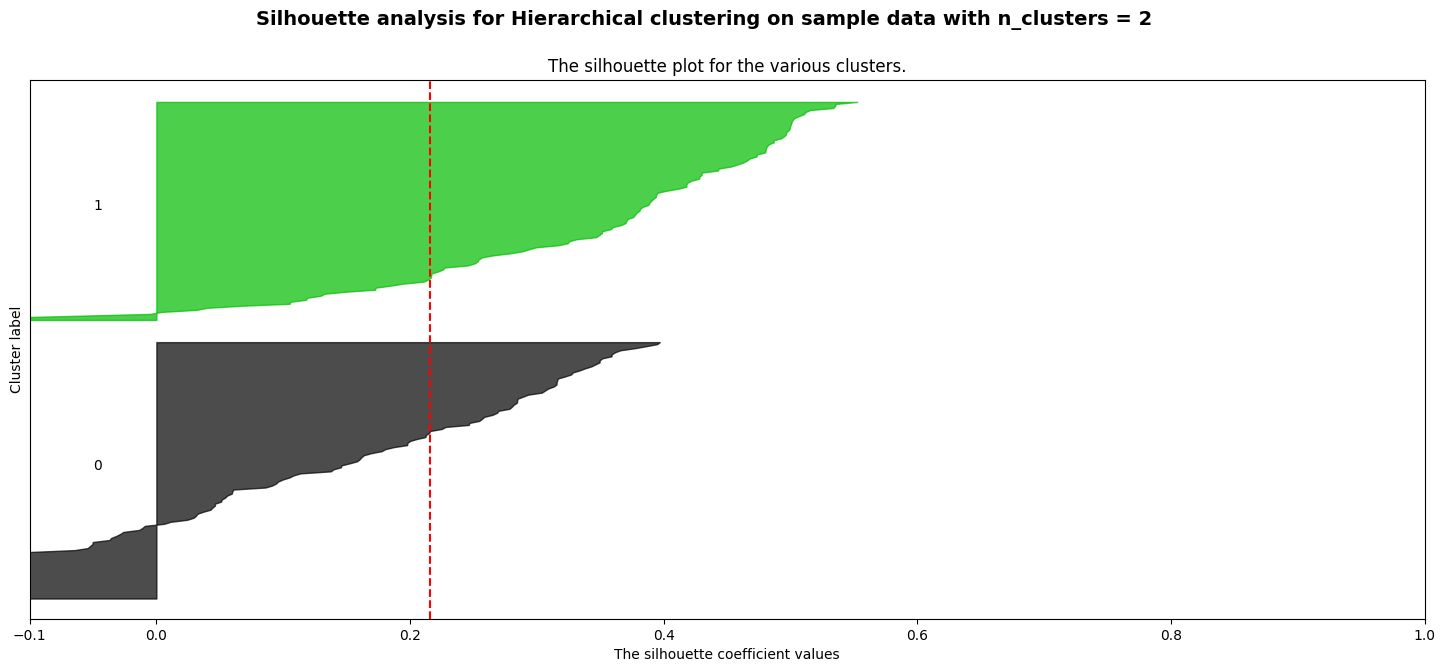

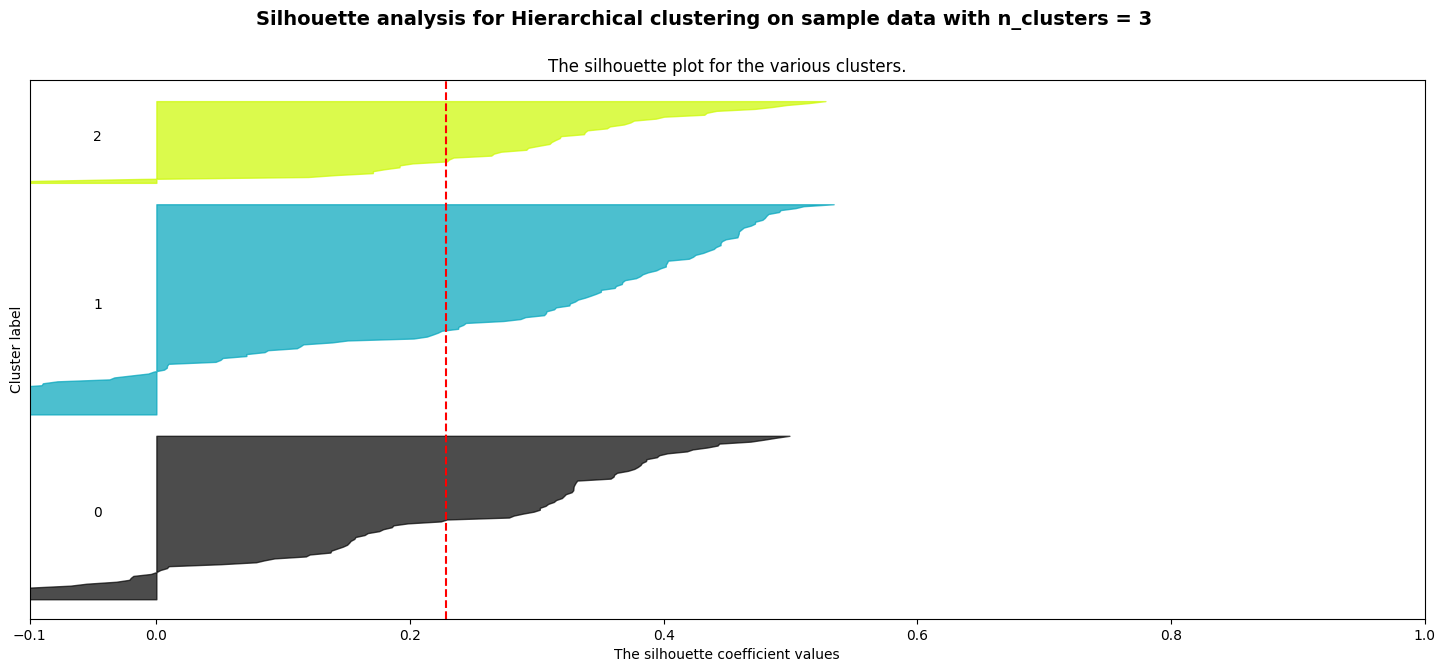

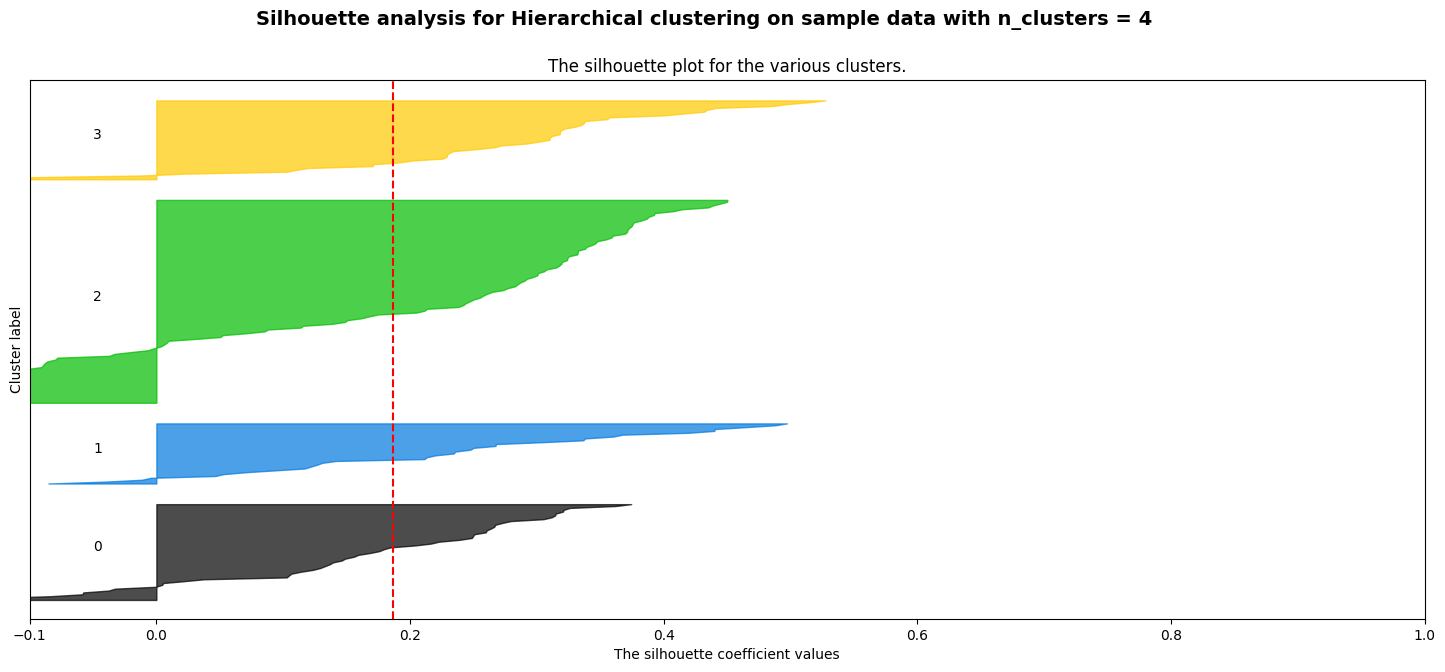

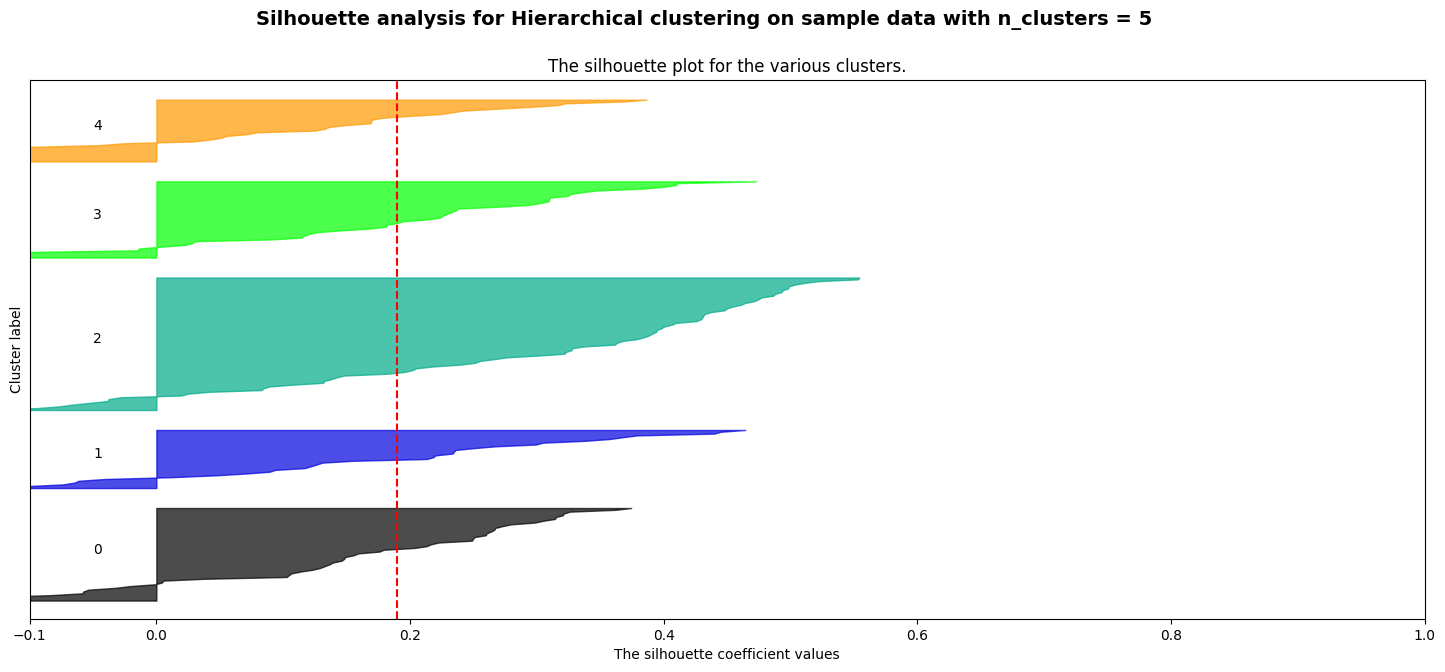

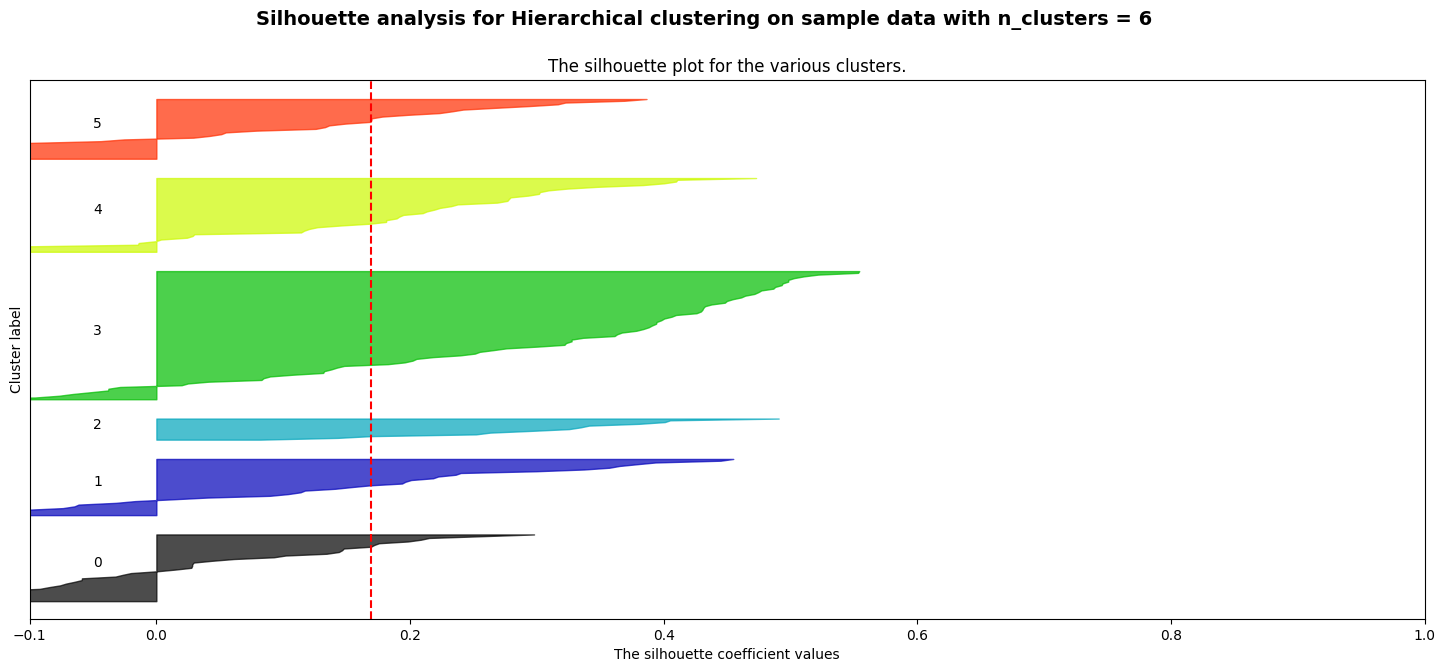

In [379]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from scipy.cluster import hierarchy
from sklearn.metrics import silhouette_samples, silhouette_score

range_n_clusters = [2, 3, 4, 5, 6]
sil_hierarchical = {}

# Compute the hierarchical clustering linkage once
hc_comp_cos = hierarchy.linkage(low_dim_df, method="complete", metric="cosine")

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 1 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(low_dim_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    cluster_labels = hierarchy.cut_tree(hc_comp_cos, n_clusters=n_clusters)
    cluster_labels = cluster_labels[:, 0]

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(
        low_dim_df,
        cluster_labels,
        metric="cosine"
    )
    sil_hierarchical[n_clusters] = silhouette_avg
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(
        low_dim_df,
        cluster_labels,
        metric="cosine"
    )

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        "Silhouette analysis for Hierarchical clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

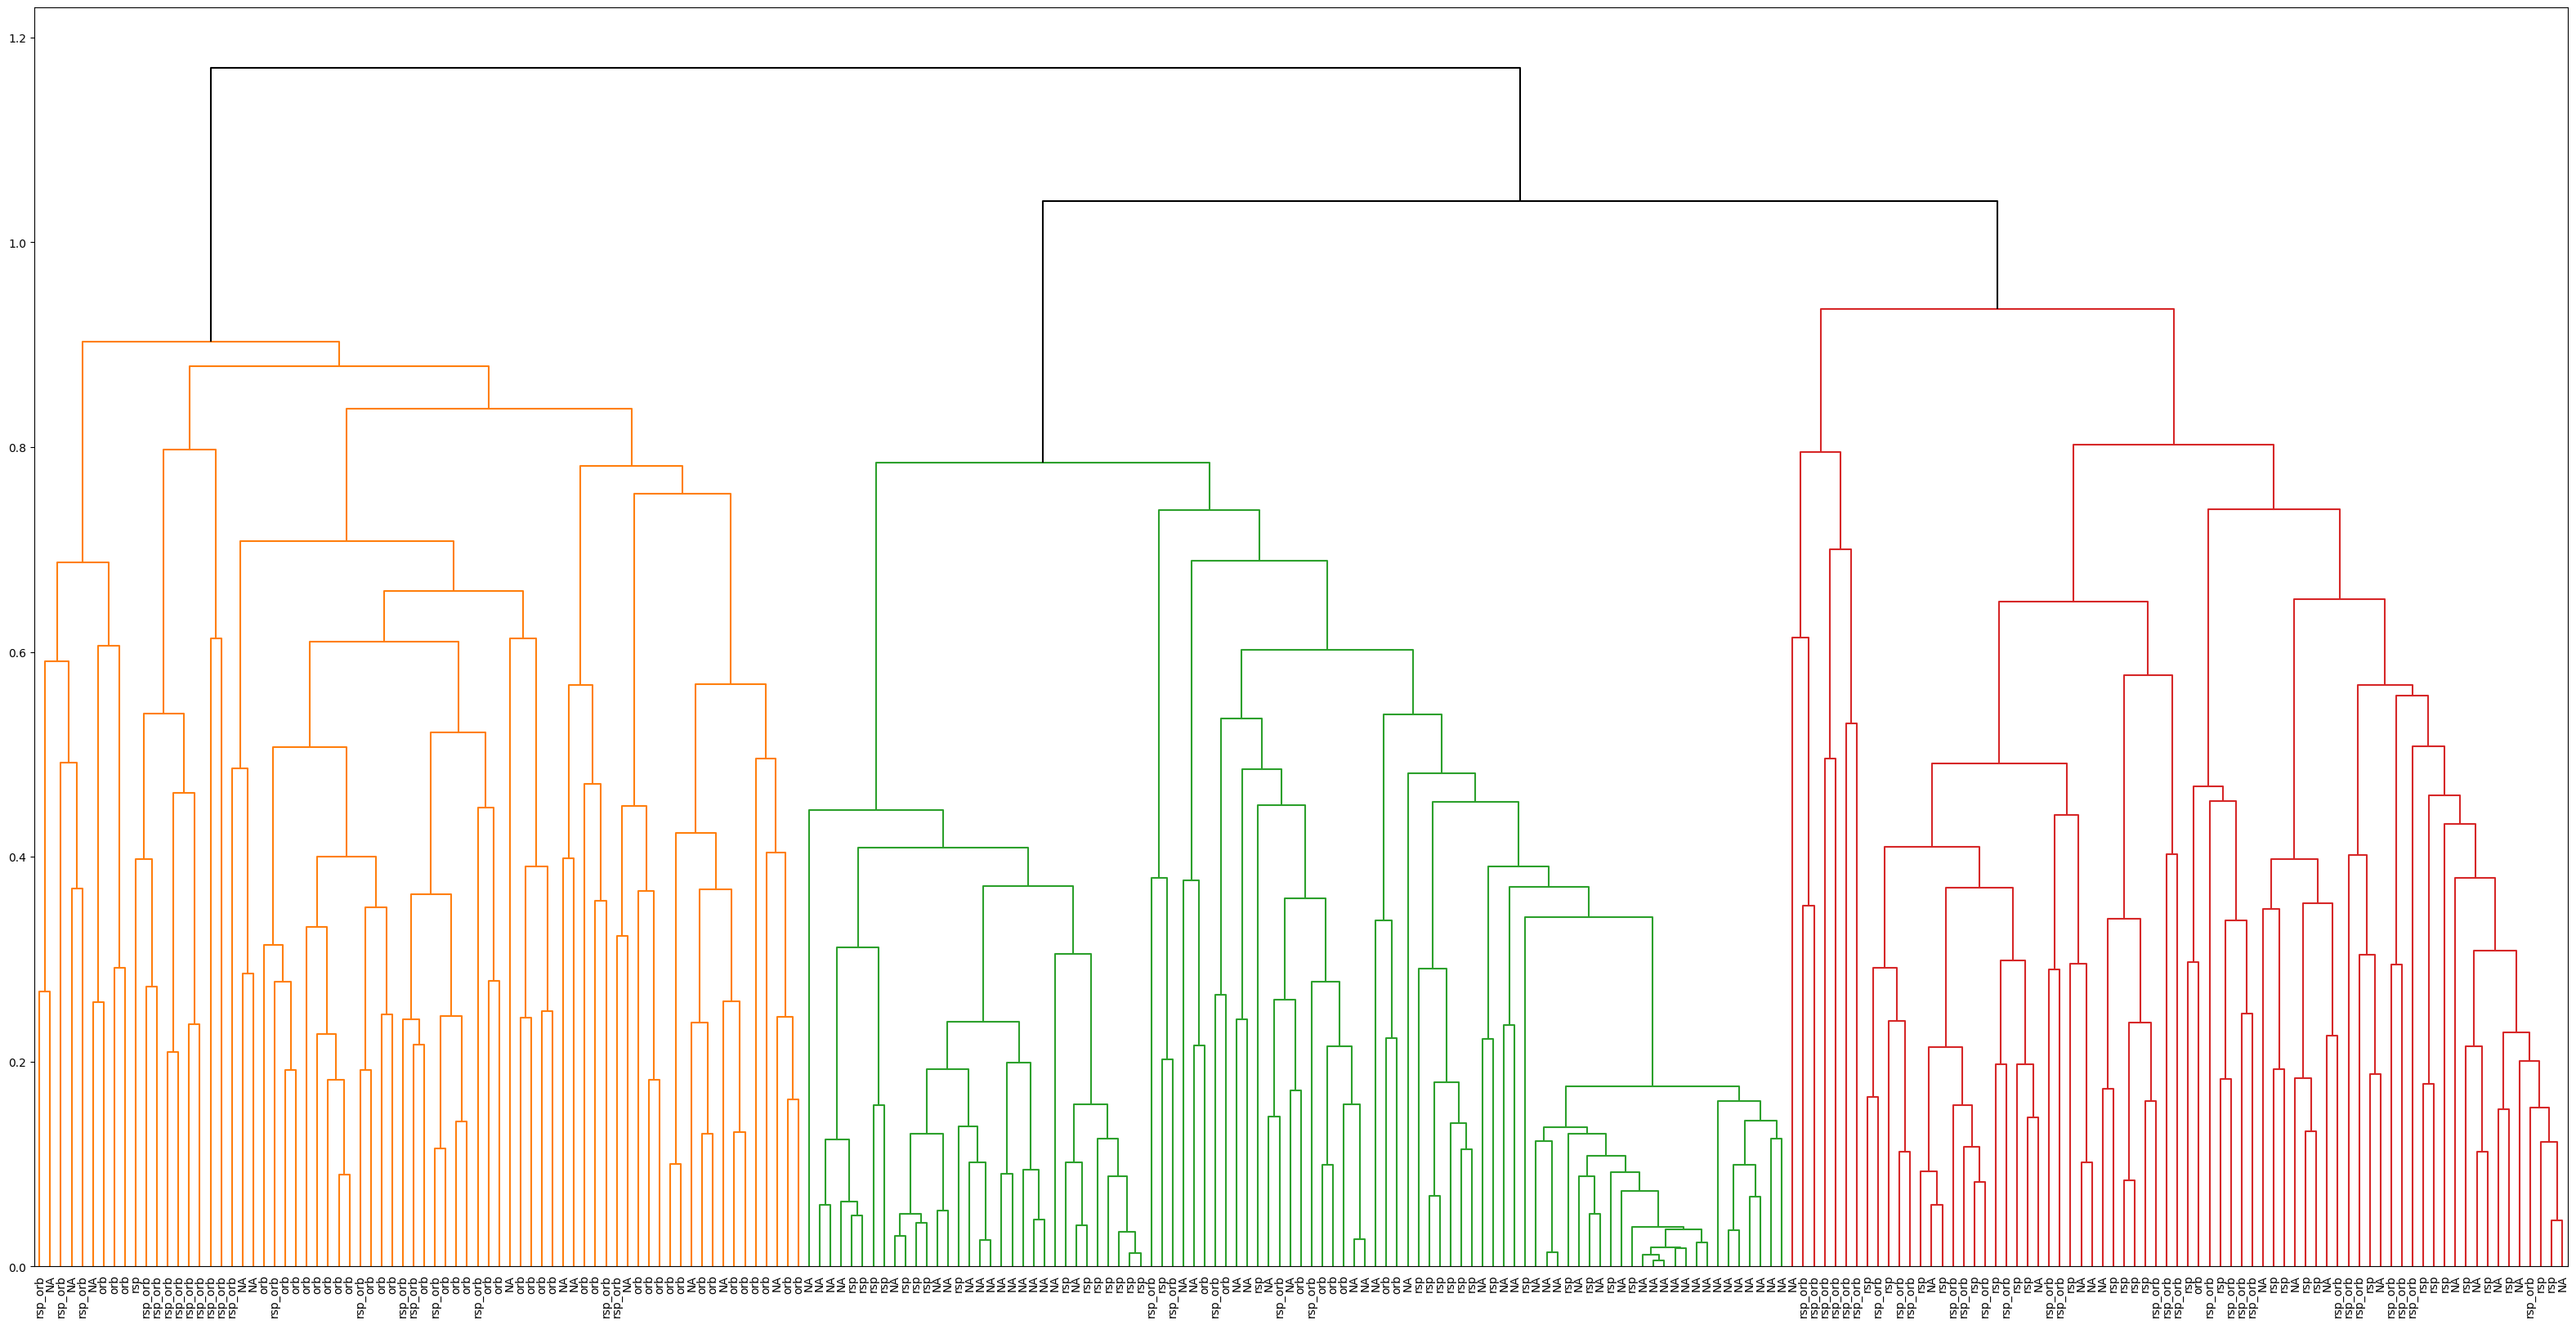

In [380]:
hc_avg_cos = hierarchy.linkage(low_dim_df, method="average", metric="cosine")
# Plot the dendrogram
fig, ax = plt.subplots(1, 1, figsize=(40,20))
hierarchy.dendrogram(hc_avg_cos, ax=ax, labels=np.asarray(labels),
                     color_threshold=1, above_threshold_color='black', leaf_font_size = 10)
plt.show()

In [381]:
cluster_labels = hierarchy.cut_tree(hc_avg_cos, height=1)
cluster_labels_1d_3 = cluster_labels[:, 0]

plot_df3 = low_dim_df.copy()
plot_df3.columns = [f"Dim_{i+1}" for i in range(plot_df3.shape[1])]
plot_df3["cluster"] = cluster_labels_1d_3.astype(str)

fig = px.scatter_3d(
    plot_df3,
    x="Dim_1",
    y="Dim_2",
    z="Dim_3",
    color="cluster",
    hover_data=plot_df3.columns)

fig.show()

ct = pd.crosstab(cluster_labels_1d_3, labels)
print(ct)

proj   NA  orb  rsp  rsp_orb
row_0                       
0      12   39    1       20
1      50    8   29        5
2      15    1   28       29


In [382]:
wcv_avg_cos = compute_wcv(cluster_labels_1d_3, low_dim_df)
print(f"Total WCV: {wcv_avg_cos}")

Total WCV: 4639.357046789479


For n_clusters = 2 The average silhouette_score is : 0.27781746884823555
For n_clusters = 3 The average silhouette_score is : 0.298863658449836
For n_clusters = 4 The average silhouette_score is : 0.24935087285616475
For n_clusters = 5 The average silhouette_score is : 0.22685278429937625
For n_clusters = 6 The average silhouette_score is : 0.21320823593487237


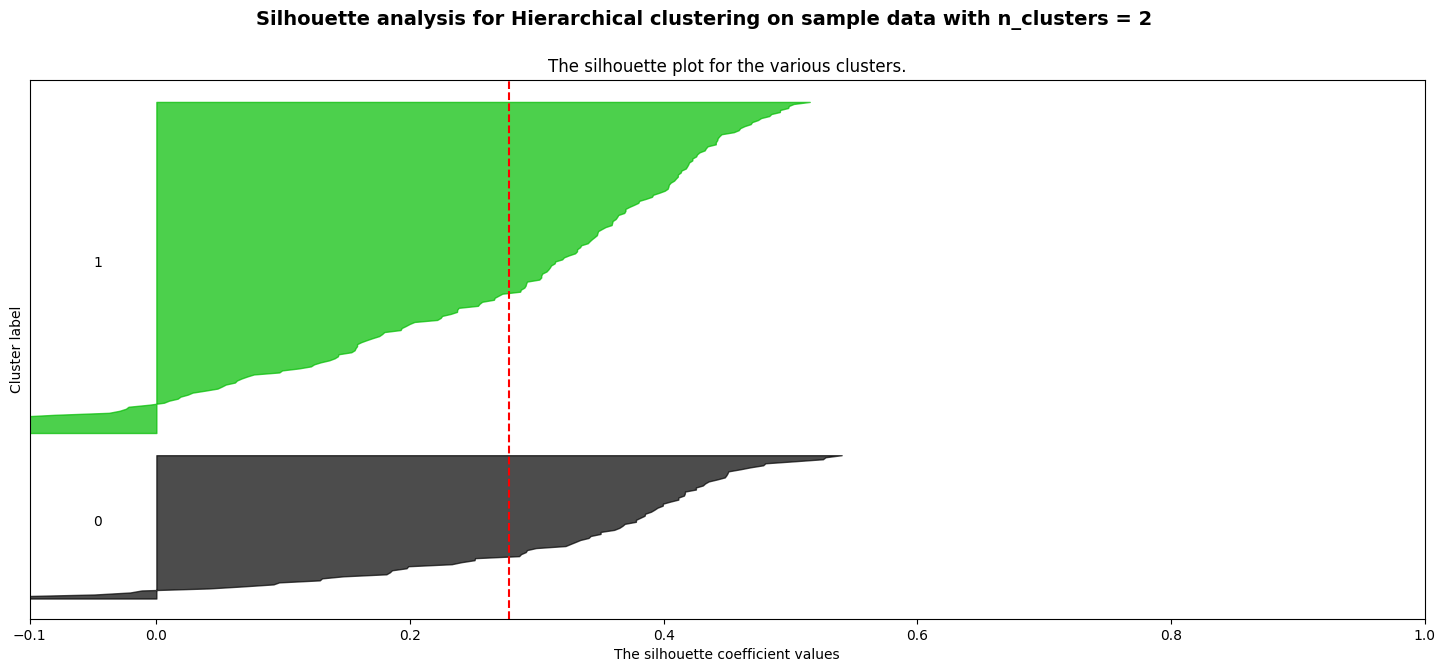

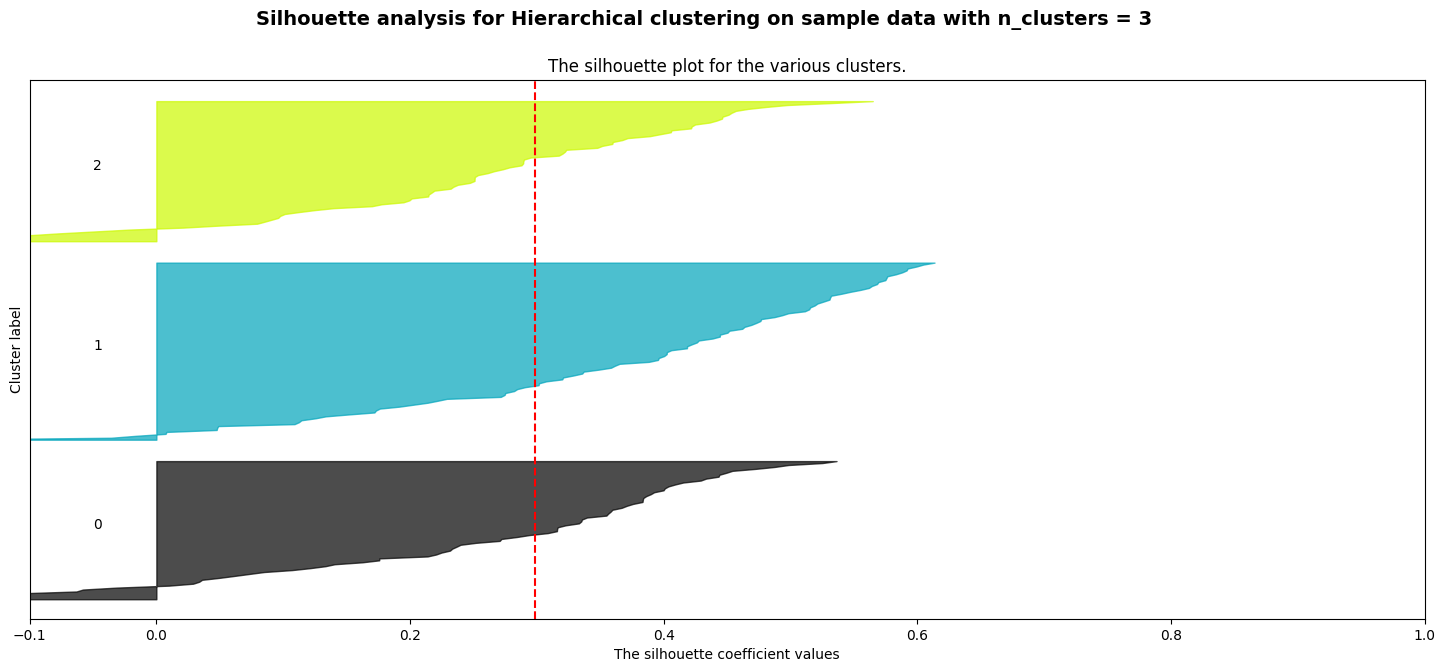

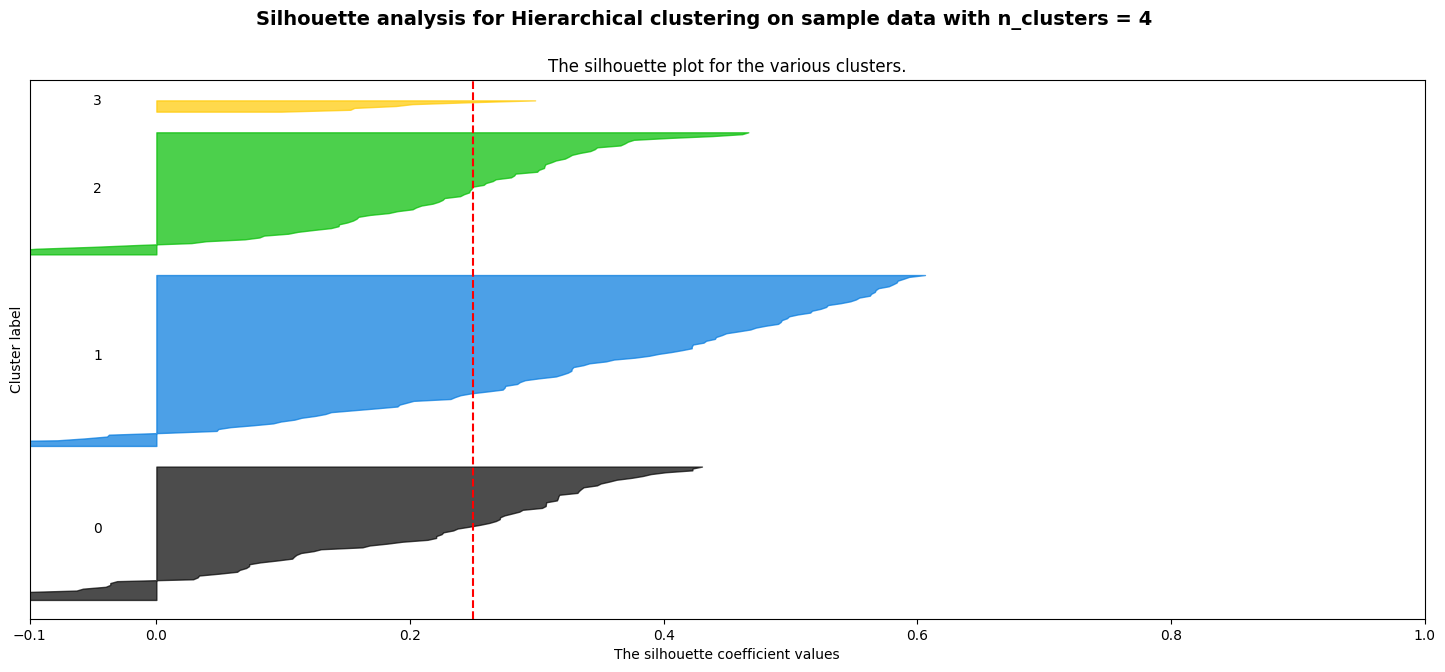

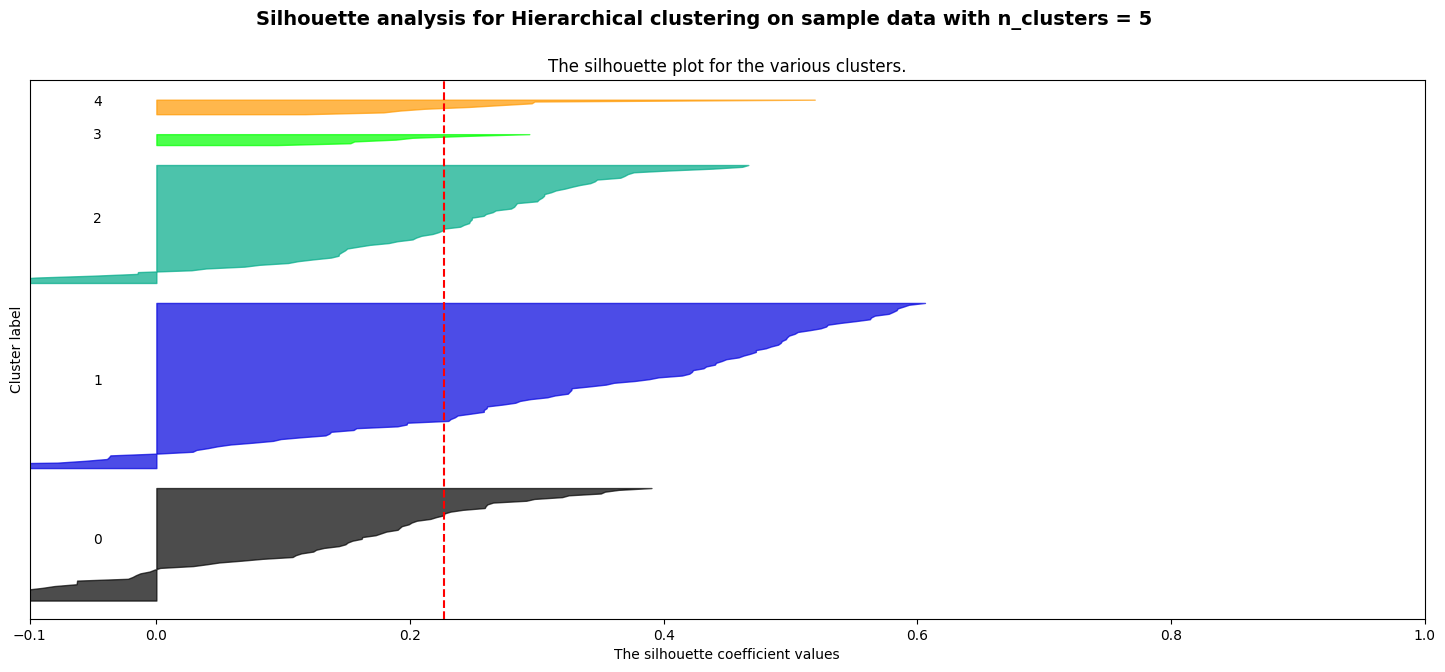

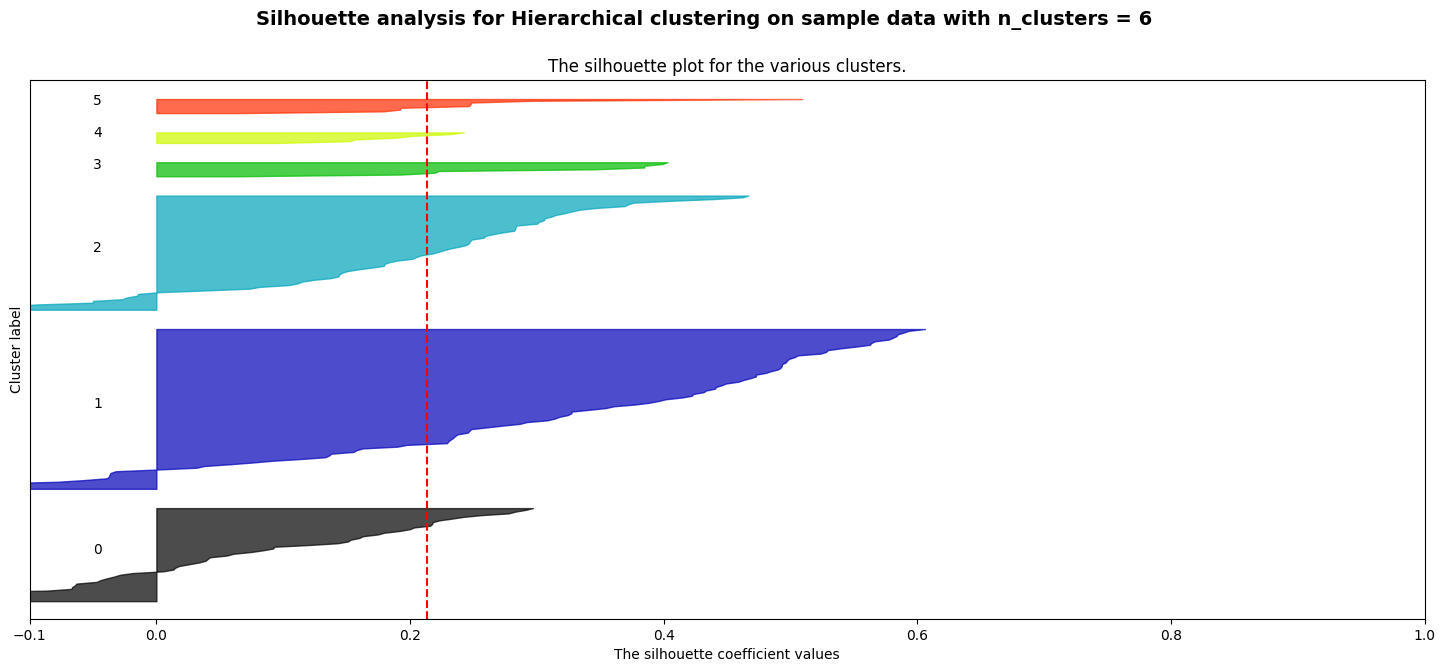

In [383]:
# Authors: The scikit-learn developers: https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from scipy.cluster import hierarchy
from sklearn.metrics import silhouette_samples, silhouette_score

range_n_clusters = [2, 3, 4, 5, 6]
# Compute the hierarchical clustering linkage once
hc_avg_cos = hierarchy.linkage(low_dim_df, method="average", metric="cosine")

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 1 columns
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(low_dim_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    cluster_labels = hierarchy.cut_tree(hc_avg_cos, n_clusters=n_clusters)
    cluster_labels = cluster_labels[:, 0]

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(
        low_dim_df,
        cluster_labels,
        metric="cosine"
    )

    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )
    sil_hierarchical[n_clusters] = silhouette_avg
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(
        low_dim_df,
        cluster_labels,
        metric="cosine"
    )

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        "Silhouette analysis for Hierarchical clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

In [384]:
# hc_comp_cos = hierarchy.linkage(low_dim_df, method="single", metric="cosine")
# # Plot the dendrogram
# fig, ax = plt.subplots(1, 1, figsize=(40,20))
# hierarchy.dendrogram(hc_comp_cos, ax=ax, labels=np.asarray(labels),
#                      color_threshold=1.5, above_threshold_color='black', leaf_font_size = 10)
# plt.show()

Try with K++ 

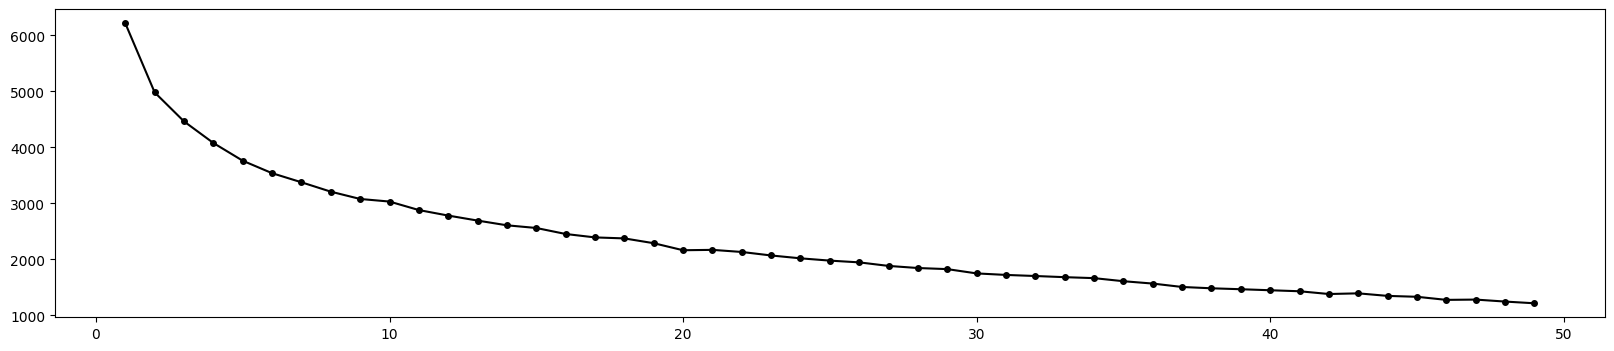

In [385]:
n_k = np.arange(1,50,1)
rs = 0
wcv = []
fig, ax = plt.subplots(1,1,figsize=(20,4))
for n in range(n_k.shape[0]):
    kmeans_n = KMeans(n_clusters = n_k[n], init = 'k-means++', n_init = 10, random_state=rs).fit(low_dim_df)
    wcv.append(kmeans_n.inertia_)
ax.plot(n_k, wcv, 'k-', marker = 'o', markersize=4)

Looks like the elbow is more or less at 4/5 clustrers but it doesnt seem that k++ captures clear clustering structure. Can try with kernel? --> spectral clustering, from scikit learn documentation: "In practice Spectral Clustering is very useful when the structure of the individual clusters is highly non-convex, or more generally when a measure of the center and spread of the cluster is not a suitable description of the complete cluster, such as when clusters are nested circles on the 2D plane."

In [386]:
wcv_kmeans = {}
for i in range(2,7):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', n_init = 15, random_state=rs).fit(low_dim_df)
    wcv_kmeans_i = kmeans.inertia_
    wcv_kmeans[i] = wcv_kmeans_i

In [387]:
cluster_labels_4 = kmeans.labels_

plot_df3 = low_dim_df.copy()
plot_df3.columns = [f"Dim_{i+1}" for i in range(plot_df3.shape[1])]
plot_df3["cluster"] = cluster_labels_4.astype(str)

fig = px.scatter_3d(
    plot_df3,
    x="Dim_1",
    y="Dim_2",
    z="Dim_3",
    color="cluster",
    hover_data=plot_df3.columns)

fig.show()

ct = pd.crosstab(cluster_labels_4, labels)
print(ct)

proj   NA  orb  rsp  rsp_orb
row_0                       
0      47   14   16        9
1       1   22    0       13
2       8    1   28       28
3      18    0   14        1
4       0    0    0        2
5       3   11    0        1


For n_clusters = 2 The average silhouette_score is : 0.3267316486605336
For n_clusters = 3 The average silhouette_score is : 0.15413966055693032
For n_clusters = 4 The average silhouette_score is : 0.15119175340745364
For n_clusters = 5 The average silhouette_score is : 0.16041032286221038
For n_clusters = 6 The average silhouette_score is : 0.16555656649178904


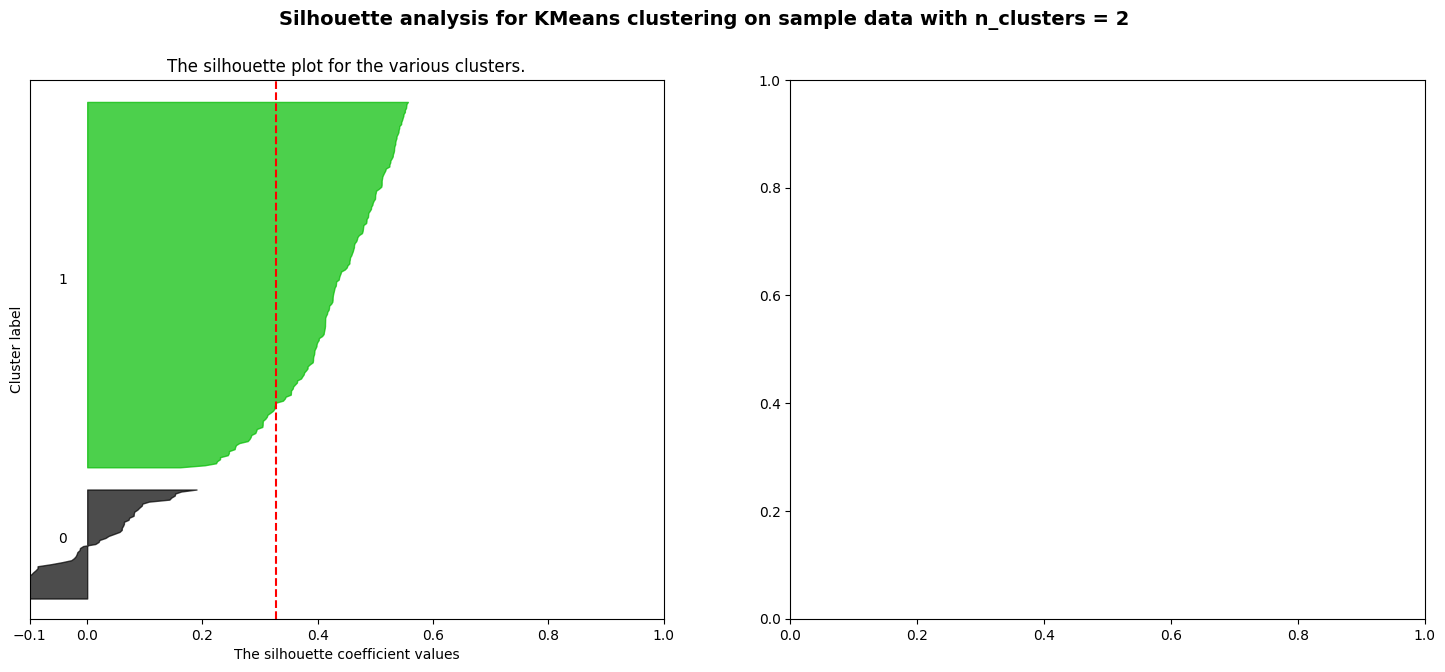

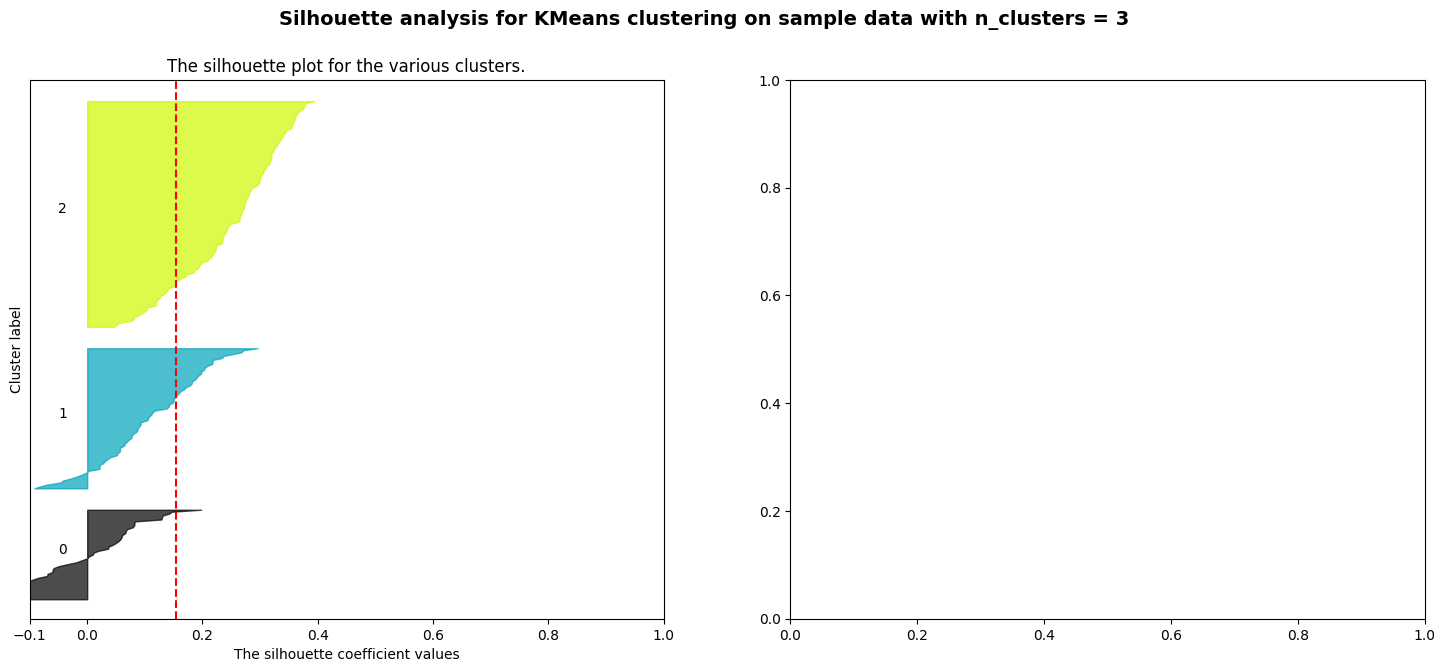

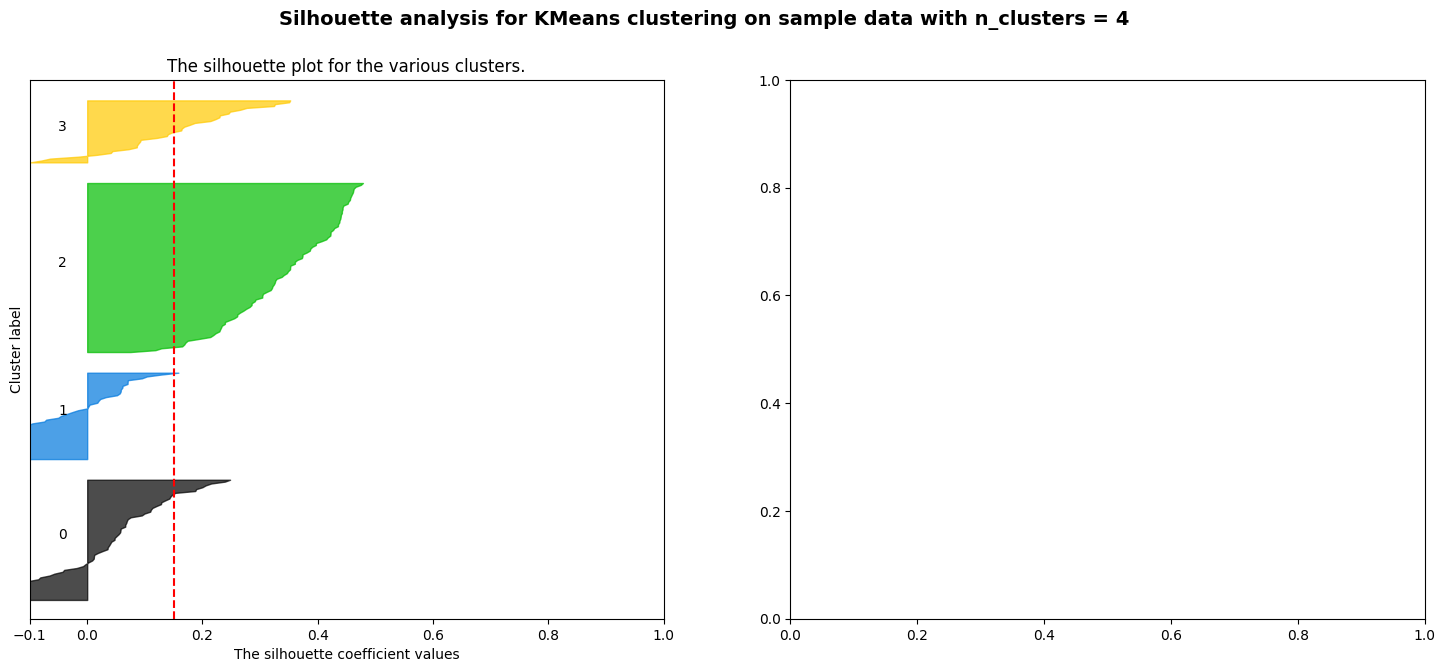

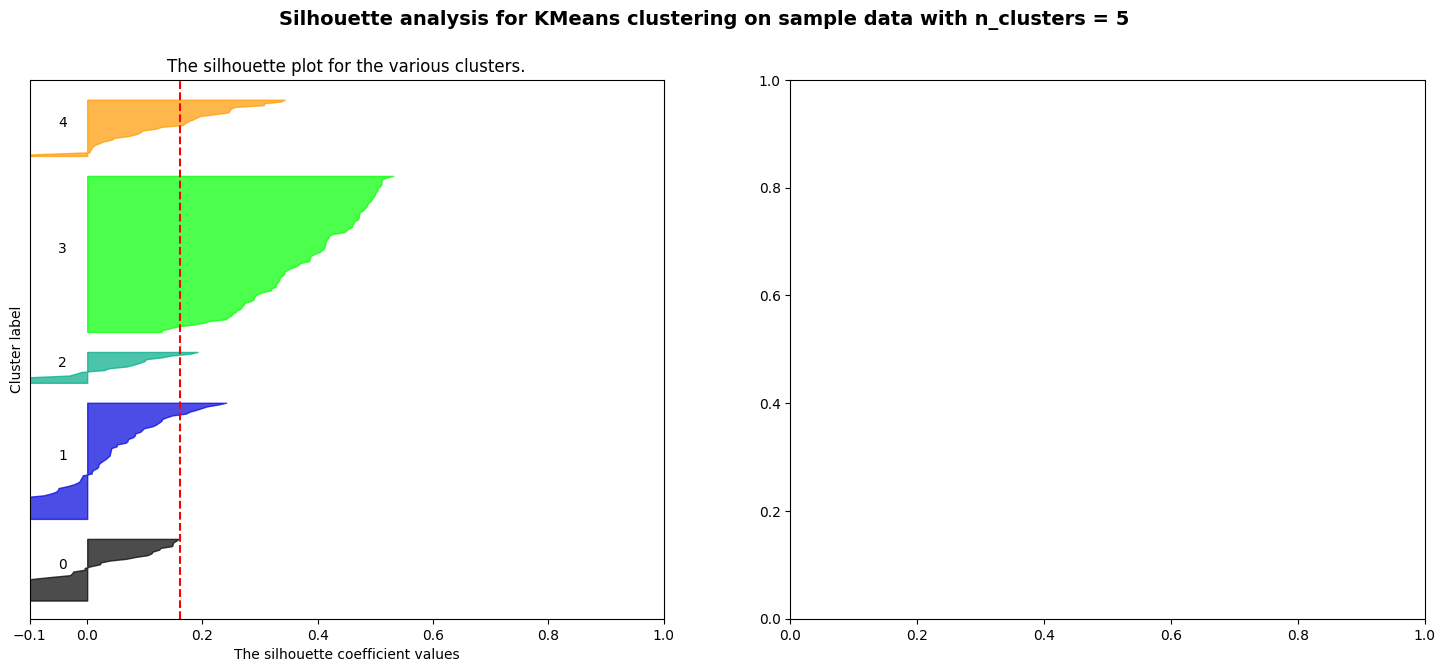

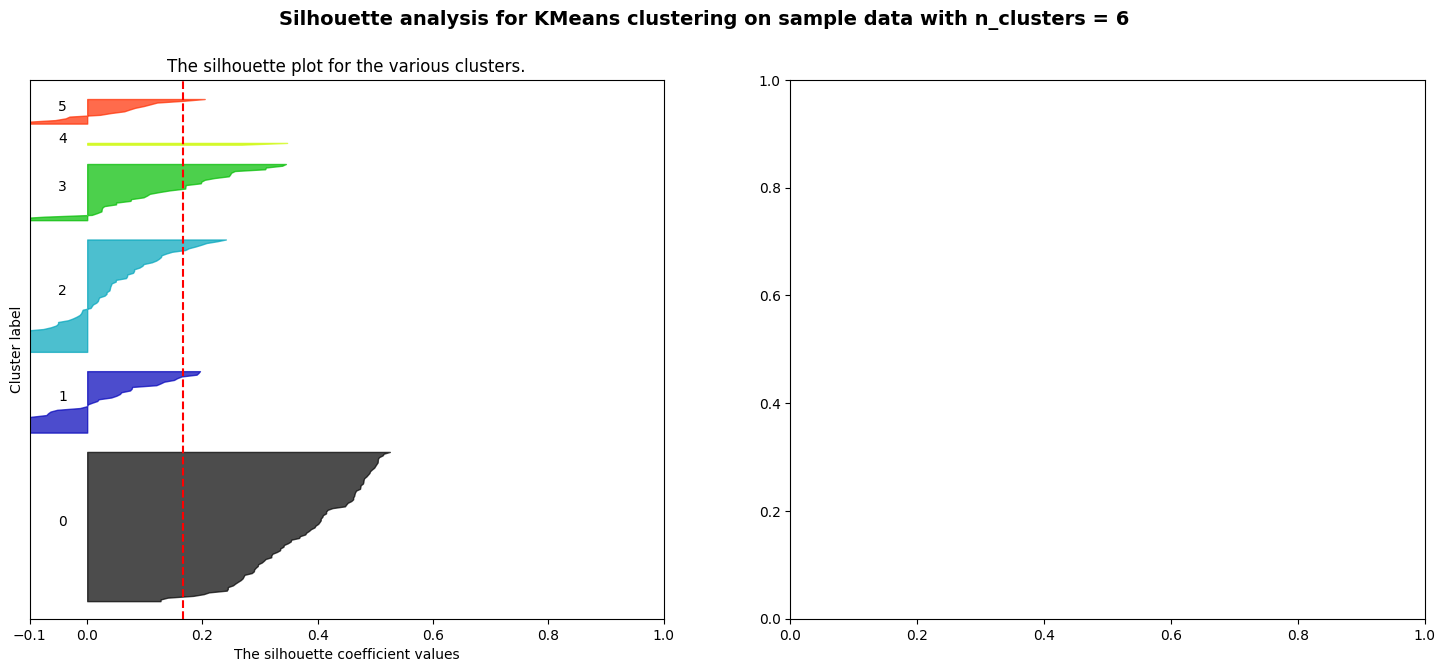

In [388]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
range_n_clusters = [2, 3, 4, 5, 6]
sil_kmeans = {}

for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(low_dim_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters = n_clusters, init = 'k-means++', n_init = 15, random_state=rs)
    cluster_labels = clusterer.fit_predict(low_dim_df)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(low_dim_df, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )
    sil_kmeans[n_clusters] = silhouette_avg
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(low_dim_df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

Spectral Clustering

In [389]:
from sklearn.cluster import SpectralClustering
spectral_clus = SpectralClustering(affinity='rbf', gamma=1, assign_labels='kmeans')

In [390]:
spectral_clus.fit(low_dim_df)

,"n_clusters n_clusters: int, default=8The dimension of the projection subspace.",8
,"eigen_solver eigen_solver: {'arpack', 'lobpcg', 'amg'}, default=NoneThe eigenvalue decomposition strategy to use. AMG requires pyamgto be installed. It can be faster on very large, sparse problems,but may also lead to instabilities. If None, then ``'arpack'`` isused. See [4]_ for more details regarding `'lobpcg'`.",None
,"n_components n_components: int, default=NoneNumber of eigenvectors to use for the spectral embedding. If None,defaults to `n_clusters`.",None
,"random_state random_state: int, RandomState instance, default=NoneA pseudo random number generator used for the initializationof the lobpcg eigenvectors decomposition when `eigen_solver =='amg'`, and for the K-Means initialization. Use an int to makethe results deterministic across calls (See:term:`Glossary `)... note:: When using `eigen_solver == 'amg'`, it is necessary to also fix the global numpy seed with `np.random.seed(int)` to get deterministic results. See https://github.com/pyamg/pyamg/issues/139 for further information.",None
,"n_init n_init: int, default=10Number of time the k-means algorithm will be run with differentcentroid seeds. The final results will be the best output of n_initconsecutive runs in terms of inertia. Only used if``assign_labels='kmeans'``.",10
,"gamma gamma: float, default=1.0Kernel coefficient for rbf, poly, sigmoid, laplacian and chi2 kernels.Ignored for ``affinity='nearest_neighbors'``, ``affinity='precomputed'``or ``affinity='precomputed_nearest_neighbors'``.",1
,"affinity affinity: str or callable, default='rbf'How to construct the affinity matrix. - 'nearest_neighbors': construct the affinity matrix by computing a graph of nearest neighbors. - 'rbf': construct the affinity matrix using a radial basis function (RBF) kernel. - 'precomputed': interpret ``X`` as a precomputed affinity matrix, where larger values indicate greater similarity between instances. - 'precomputed_nearest_neighbors': interpret ``X`` as a sparse graph of precomputed distances, and construct a binary affinity matrix from the ``n_neighbors`` nearest neighbors of each instance. - one of the kernels supported by :func:`~sklearn.metrics.pairwise.pairwise_kernels`.Only kernels that produce similarity scores (non-negative values thatincrease with similarity) should be used. This property is not checkedby the clustering algorithm.",'rbf'
,"n_neighbors n_neighbors: int, default=10Number of neighbors to use when constructing the affinity matrix usingthe nearest neighbors method. Ignored for ``affinity='rbf'``.",10
,"eigen_tol eigen_tol: float, default=""auto""Stopping criterion for eigen decomposition of the Laplacian matrix.If `eigen_tol=""auto""` then the passed tolerance will depend on the`eigen_solver`:- If `eigen_solver=""arpack""`, then `eigen_tol=0.0`;- If `eigen_solver=""lobpcg""` or `eigen_solver=""amg""`, then `eigen_tol=None` which configures the underlying `lobpcg` solver to automatically resolve the value according to their heuristics. See, :func:`scipy.sparse.linalg.lobpcg` for details.Note that when using `eigen_solver=""lobpcg""` or `eigen_solver=""amg""`values of `tol<1e-5` may lead to convergence issues and should beavoided... versionadded:: 1.2 Added 'auto' option.",'auto'
,"assign_labels assign_labels: {'kmeans', 'discretize', 'cluster_qr'}, default='kmeans'The strategy for assigning labels in the embedding space. There are twoways to assign labels after the Laplacian embedding. k-means is apopular choice, but it can be sensitive to initialization.Discretization is another approach which is less sensitive to randominitialization [3]_.The cluster_qr method [5]_ directly extract clusters from eigenvectorsin spectral clustering. In contrast to k-means and discretization, cluster_qrhas no tuning parameters and runs no iterations, yet may outperformk-means and discretization in terms of both quality and speed... versionchanged:: 1.1 Added new labeling method 'cluster_qr'

We select the value of gamma by looking at the average WCV for each level of gamma

In [391]:
n_clusters = [2,3,4,5,6,7,8]
gamma_list = np.linspace(0.0005, 0.1, 20)

tuned_spectral_clus = GridSearchCV(spectral_clus, 
                    param_grid={'gamma': gamma_list, "n_clusters": n_clusters},
                    scoring = spectral_scorer,
                    cv = KFold(n_splits=5, shuffle = True, random_state=rng)) 

In [392]:
tuned_spectral_clus.fit(low_dim_df)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SpectralClustering(gamma=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': array([0.0005..., 0.1 ]), 'n_clusters': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",<function spe...002E068765F80>
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [393]:
cv_results = pd.DataFrame(tuned_spectral_clus.cv_results_)

gamma_summary = (cv_results.groupby("param_gamma").agg(
        mean_score=("mean_test_score", "mean"),
        max_score=("mean_test_score", "max"),
        std_score=("mean_test_score", "std")
    )
    .sort_values("mean_score", ascending=False)
)

gamma_summary.head()

,mean_score,max_score,std_score
param_gamma,,,
0.010974,-659.562630,-456.006399,175.439382
0.016211,-665.672992,-445.214062,179.161187
0.005737,-666.706418,-474.121904,170.282952
0.000500,-675.874016,-492.313499,164.638768
0.021447,-676.132471,-486.968504,168.386400


Plot wcv vs gamma and wcv vs n_clusters --> choose paramteres, fit the corresponding model.


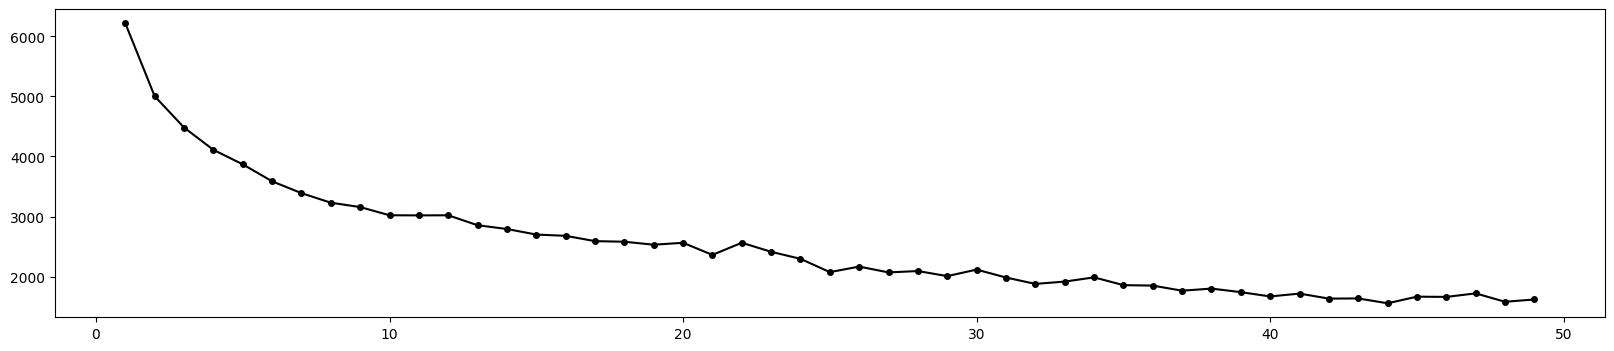

In [394]:
n_k = np.arange(1,50,1)
rs = 0
wcv = []
fig, ax = plt.subplots(1,1,figsize=(20,4))
for n in range(n_k.shape[0]):
    spectral_clus_tuned = SpectralClustering(affinity='rbf', assign_labels='kmeans', gamma=0.010974, n_clusters=n_k[n])
    labels = spectral_clus_tuned.fit_predict(low_dim_df)
    wcv_temp = compute_wcv(labels, low_dim_df)
    wcv.append(wcv_temp)
ax.plot(n_k, wcv, 'k-', marker = 'o', markersize=4)

5/6 clusters seems to be the most suitable choice also in this case

In [395]:
wcv_spectral = {}
for i in range(2,7):
    spectral_clus_tuned = SpectralClustering(affinity='rbf', assign_labels='kmeans', gamma=0.010974, n_clusters=i)
    labels_spec = spectral_clus_tuned.fit_predict(low_dim_df)
    wcv_spec_i = compute_wcv(labels_spec, low_dim_df)
    wcv_spectral[i] = wcv_spec_i

In [396]:
cluster_labels_5 = compute_wcv(labels_spec, low_dim_df)

plot_df3 = low_dim_df.copy()
plot_df3.columns = [f"Dim_{i+1}" for i in range(plot_df3.shape[1])]
plot_df3["cluster"] = cluster_labels_4.astype(str)

fig = px.scatter_3d(
    plot_df3,
    x="Dim_1",
    y="Dim_2",
    z="Dim_3",
    color="cluster",
    hover_data=plot_df3.columns)

fig.show()

ct = pd.crosstab(cluster_labels_5, labels_spec)
print(ct)

col_0        0    1   2   3  4  5
row_0                            
3598.31257  56  103  44  27  5  2


For n_clusters = 2 The average silhouette_score is : 0.3492075077766297
For n_clusters = 3 The average silhouette_score is : 0.15205162729803343
For n_clusters = 4 The average silhouette_score is : 0.16481804570385516
For n_clusters = 5 The average silhouette_score is : 0.17694750786785107
For n_clusters = 6 The average silhouette_score is : 0.18101958052830308


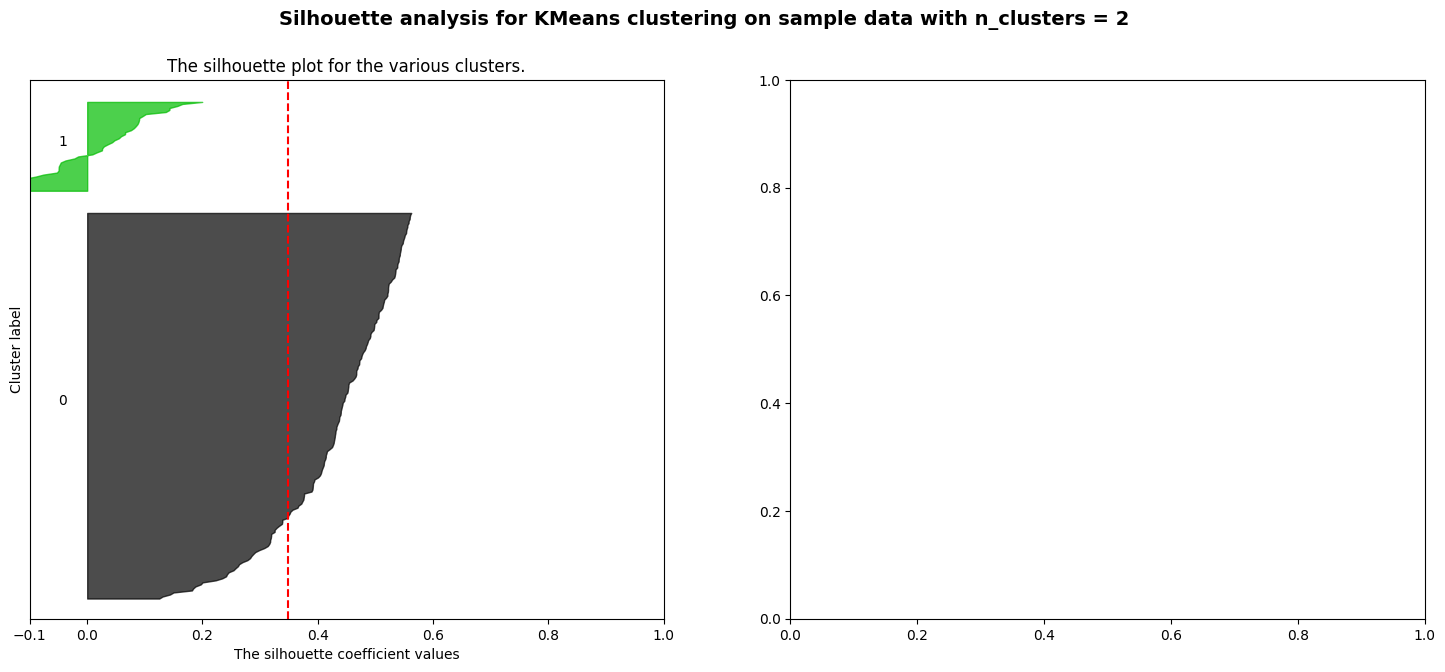

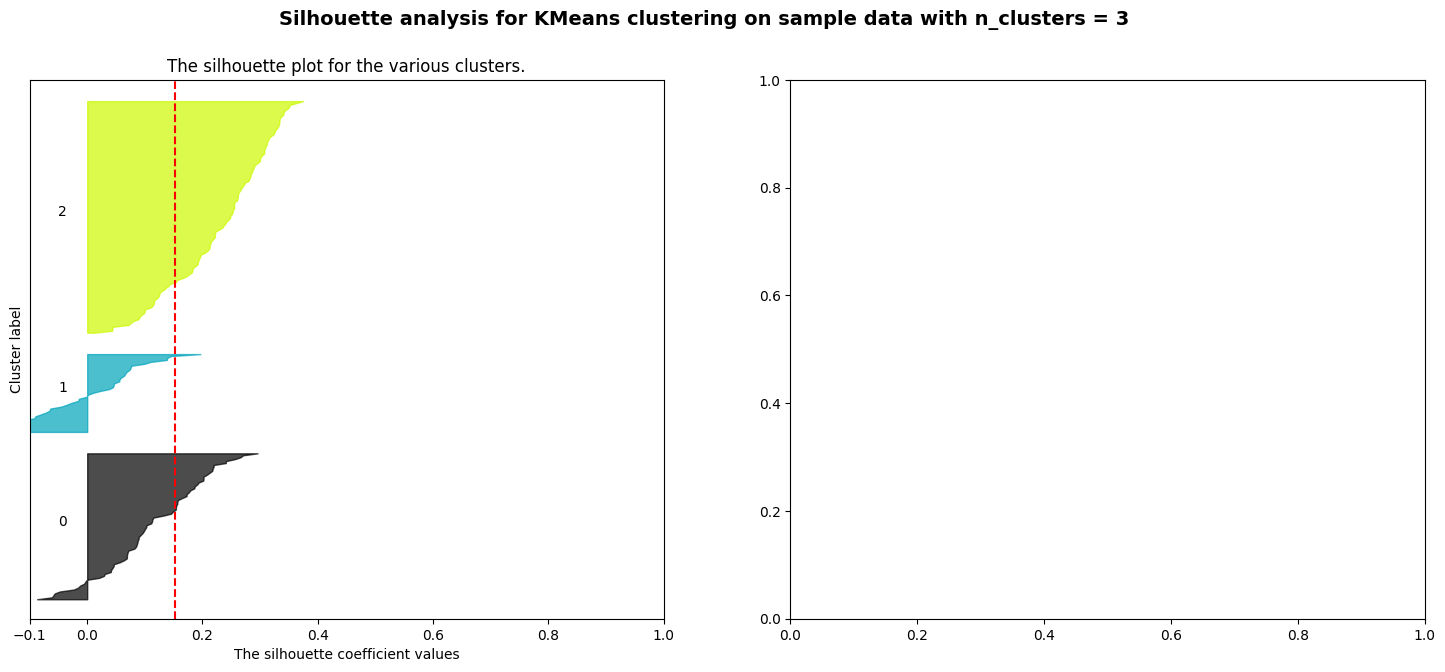

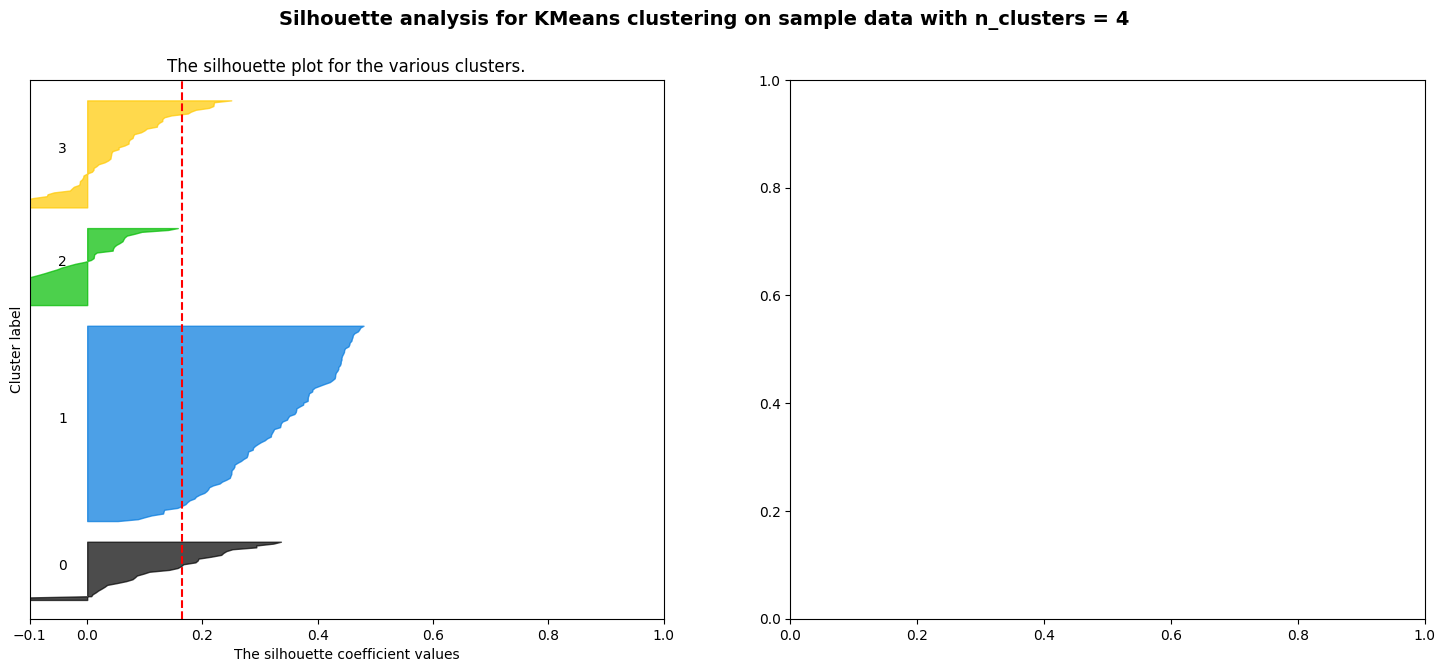

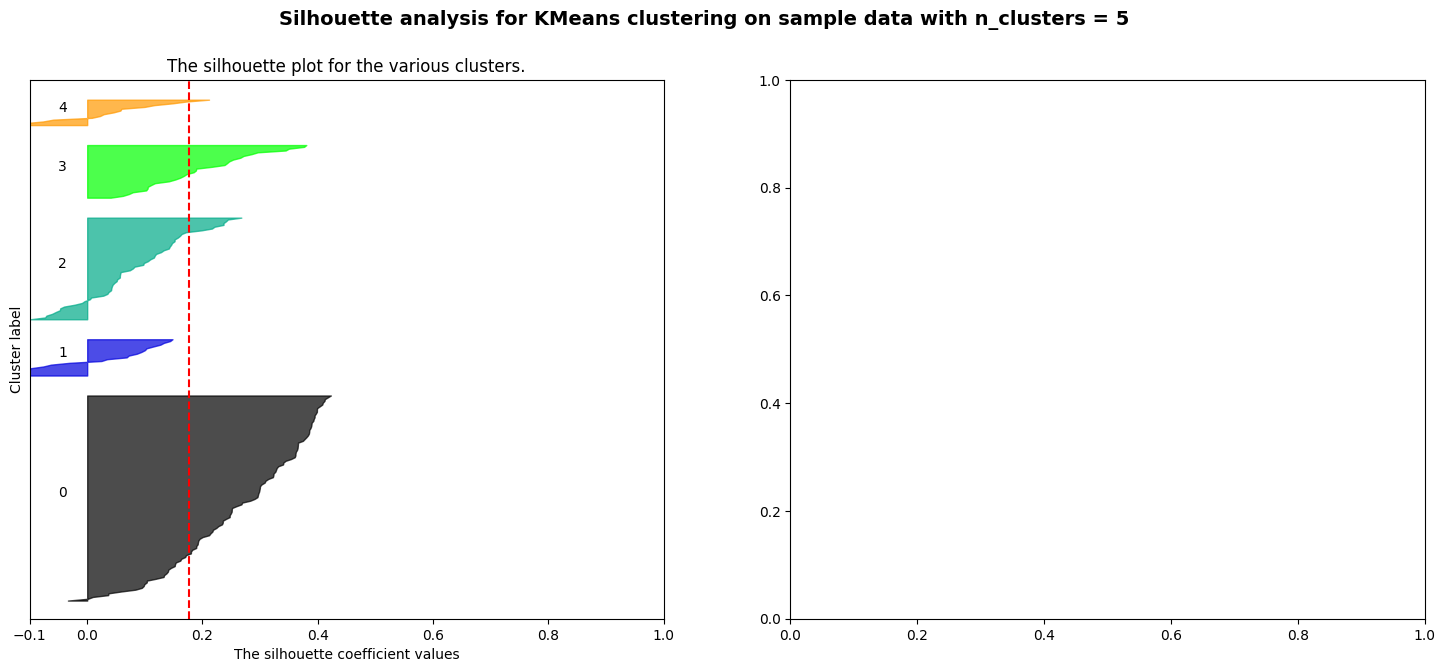

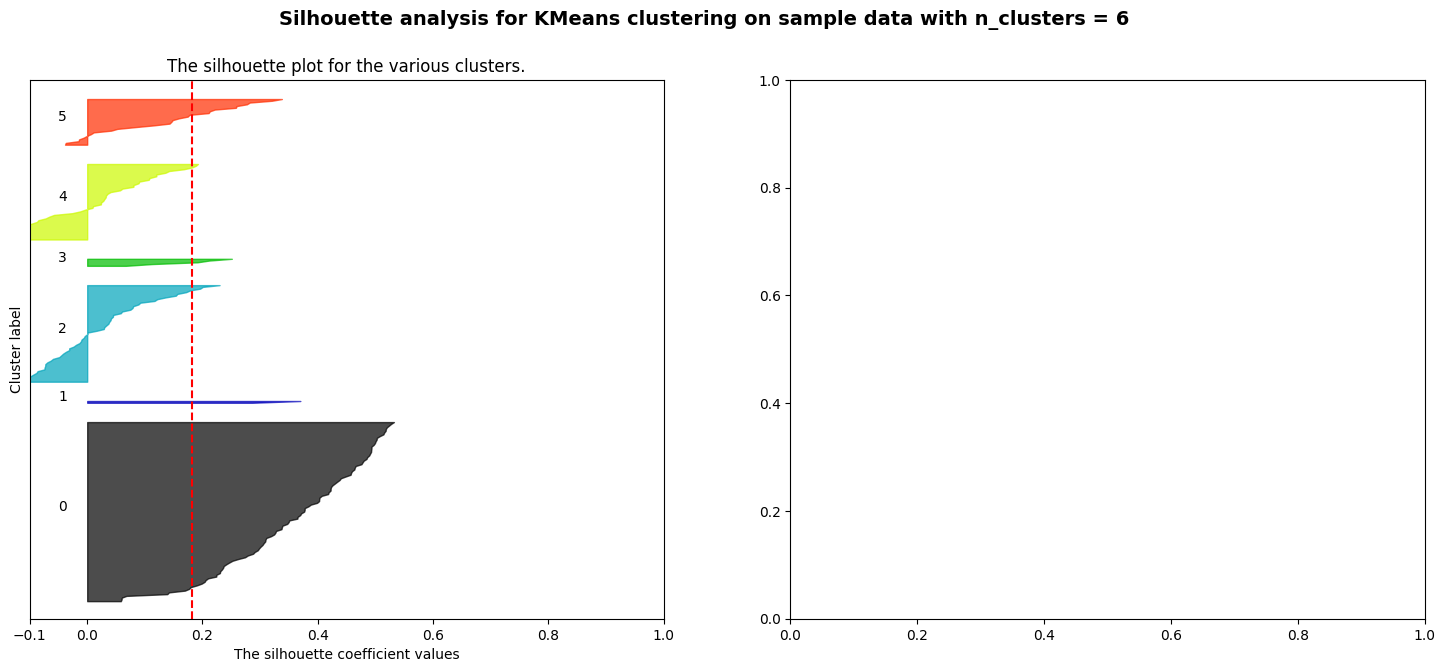

In [397]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

# Generating the sample data from make_blobs
# This particular setting has one distinct cluster and 3 clusters placed close
# together.
range_n_clusters = [2, 3, 4, 5, 6]
sil_spectral = {}
for n_clusters in range_n_clusters:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(low_dim_df) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = SpectralClustering(affinity='rbf', assign_labels='kmeans', gamma=0.010974, n_clusters=n_clusters)
    cluster_labels = clusterer.fit_predict(low_dim_df)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(low_dim_df, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )
    sil_spectral[n_clusters] = silhouette_avg
    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(low_dim_df, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

Summary on clustering


In [398]:
summary_table = pd.DataFrame(
    {
        (2, "WCV"): [
            wcv_comp_cos[2],
            wcv_kmeans[2],
            wcv_spectral[2]
        ],
        (2, "Silhouette"): [
            sil_hierarchical[2],
            sil_kmeans[2],
            sil_spectral[2]
        ],

        (3, "WCV"): [
            wcv_comp_cos[3],
            wcv_kmeans[3],
            wcv_spectral[3]
        ],
        (3, "Silhouette"): [
            sil_hierarchical[3],
            sil_kmeans[3],
            sil_spectral[3]
        ],

        (4, "WCV"): [
            wcv_comp_cos[4],
            wcv_kmeans[4],
            wcv_spectral[4]
        ],
        (4, "Silhouette"): [
            sil_hierarchical[4],
            sil_kmeans[4],
            sil_spectral[4]
        ],

        (5, "WCV"): [
            wcv_comp_cos[5],
            wcv_kmeans[5],
            wcv_spectral[5]
        ],
        (5, "Silhouette"): [
            sil_hierarchical[5],
            sil_kmeans[5],
            sil_spectral[5]
        ],

        (6, "WCV"): [
            wcv_comp_cos[6],
            wcv_kmeans[6],
            wcv_spectral[6]
        ],
        (6, "Silhouette"): [
            sil_hierarchical[6],
            sil_kmeans[6],
            sil_spectral[6]
        ],
    },
    index=["Hierarchical", "KMeans++", "Spectral"]
)

summary_table.columns.names = ["n_clusters", "Metric"]

summary_table

n_clusters              2                       3                       4  \
Metric                WCV Silhouette          WCV Silhouette          WCV   
Hierarchical  5487.769402   0.277817  4875.453064   0.298864  4548.607835   
KMeans++      4983.234966   0.326732  4464.882240   0.154140  4075.104022   
Spectral      5004.109124   0.349208  4482.718659   0.152052  4110.701873   

n_clusters                         5                       6             
Metric       Silhouette          WCV Silhouette          WCV Silhouette  
Hierarchical   0.249351  4341.429051   0.226853  4091.896539   0.213208  
KMeans++       0.151192  3754.501157   0.160410  3539.525933   0.165557  
Spectral       0.164818  3869.816545   0.176948  3598.312570   0.181020